In [1]:
!pip -q install lightgbm requests-cache retry-requests     scikit-learn pandas numpy matplotlib folium joblib pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00


The `find_file` function will now search in your mounted Google Drive for the dataset files, eliminating the need to upload them manually.

In [2]:
# --- Standard library imports ---
from pathlib import Path      # convenient, OS-independent filesystem paths
import json                   # saving/loading the metadata dict at the end of the pipeline
import math                   # used later for haversine distance / trig in scoring functions
import random                 # Python's built-in RNG, seeded below for reproducible negative sampling etc.
import warnings                # to silence noisy library warnings so notebook output stays readable
import shutil                  # used later to zip up the results folder for download

# --- Data handling and plotting ---
import numpy as np             # numerical arrays, used throughout for vectorised feature math
import pandas as pd            # the core DataFrame library — check-ins, POIs, itineraries all live in DataFrames
import matplotlib.pyplot as plt  # for the performance charts and risk/exposure plots later

# --- Weather API support ---
import requests_cache          # caches HTTP responses to disk so re-running the notebook doesn't re-hit Open-Meteo
from retry_requests import retry  # wraps the HTTP session with automatic retry/backoff on transient failures

# --- Model persistence and mapping ---
import joblib                  # saves/loads the trained sklearn/LightGBM pipelines to disk (MODEL_DIR)
import folium                  # renders the interactive itinerary maps in Section 22

# --- scikit-learn: preprocessing, pipeline, and evaluation ---
from sklearn.compose import ColumnTransformer   # applies different preprocessing to categorical vs numeric columns
from sklearn.preprocessing import OneHotEncoder # encodes tourism_category/city/time_period for the model
from sklearn.pipeline import Pipeline           # chains preprocessing + model into one fit/predict object
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)  # the full set of classification metrics used in the Section 9 model comparison table
from sklearn.inspection import permutation_importance  # measures per-feature contribution to AUC (Section 10)

# --- The actual scoring model ---
from lightgbm import LGBMClassifier   # gradient-boosted decision tree classifier — the "learning" half of the system

# --- Notebook-wide settings ---
warnings.filterwarnings("ignore")     # suppress sklearn/LightGBM deprecation & convergence warnings in output
pd.set_option("display.max_columns", 120)  # let wide DataFrames (40+ feature columns) print without truncation
pd.set_option("display.width", 180)        # widen the display so those columns don't wrap awkwardly

# --- Reproducibility ---
SEED = 42
random.seed(SEED)      # fixes Python's random module (used in category negative-sampling)
np.random.seed(SEED)   # fixes NumPy's RNG (used in array sampling, model random_state defaults, etc.)
# Note: this seeds the LEGACY np.random global state; the newer np.random.default_rng() calls
# used elsewhere in the notebook take their own explicit seed and are unaffected by this line.

# --- Project folder structure ---
ROOT = Path("/content/weather_aware_itinerary_v3")  # Colab-specific root; change this if running locally
DATA_DIR = ROOT / "data"        # raw + uploaded TSMC2014 check-in files live here
CACHE_DIR = ROOT / "cache"      # requests_cache's SQLite cache file for weather API responses
MODEL_DIR = ROOT / "models"     # saved LightGBM/sklearn pipelines (.joblib)
RESULT_DIR = ROOT / "results"   # output CSVs — metrics, itineraries, sensitivity tables
FIGURE_DIR = RESULT_DIR / "figures"  # saved matplotlib PNGs
MAP_DIR = RESULT_DIR / "maps"        # saved Folium HTML maps

# Create every directory up front so later cells can just write files without
# checking existence first; exist_ok=True makes this safe to re-run.
for folder in [DATA_DIR, CACHE_DIR, MODEL_DIR, RESULT_DIR, FIGURE_DIR, MAP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: /content/weather_aware_itinerary_v3


Locate or Upload the Dataset

In [3]:
NYC_CANDIDATES = [
    "dataset_TSMC2014_NYC.txt",
    "dataset_TSMC2014_NYC(2).txt",
    "dataset_TSMC2014_NYC (2).txt",
]
TKY_CANDIDATES = ["dataset_TSMC2014_TKY.txt"]

SEARCH_ROOTS = [
    Path("/content"),
    Path("/content/drive/MyDrive"),
    DATA_DIR,
]

def find_file(candidates):
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for candidate in candidates:
            direct = root / candidate
            if direct.exists():
                return direct
        for candidate in candidates:
            matches = list(root.rglob(candidate))
            if matches:
                return matches[0]
    return None

nyc_path = find_file(NYC_CANDIDATES)
tky_path = find_file(TKY_CANDIDATES)

if nyc_path is None or tky_path is None:
    from google.colab import files
    print("Upload the NYC and Tokyo TSMC2014 text files.")
    uploaded = files.upload()
    for name, content in uploaded.items():
        (DATA_DIR / name).write_bytes(content)
    nyc_path = find_file(NYC_CANDIDATES)
    tky_path = find_file(TKY_CANDIDATES)

assert nyc_path is not None, "NYC file not found."
assert tky_path is not None, "Tokyo file not found."

print("NYC:", nyc_path)
print("Tokyo:", tky_path)

NYC: /content/dataset_TSMC2014_NYC.txt
Tokyo: /content/dataset_TSMC2014_TKY.txt


## 2. Load, validate, and clean the check-ins

In [4]:
# Column names for the TSMC2014 dataset
COLUMNS = [
    "user_id", "venue_id", "venue_category_id", "venue_category",
    "latitude", "longitude", "timezone_offset_minutes", "utc_time"
]

# Function to load a dataset and assign the city name
def load_tsmc(path, city):
    # Read the tab-separated text file into a DataFrame
    df = pd.read_csv(
        path,
        sep="\t",                  # Columns are separated by tabs
        header=None,               # File has no header row
        names=COLUMNS,             # Assign column names
        encoding="latin1",         # Character encoding
        on_bad_lines="skip",       # Skip any invalid rows
        low_memory=False,          # Read file using consistent data types
    )

    # Add a new column to identify the city
    df["city"] = city

    return df

# Load the New York and Tokyo datasets
nyc_raw = load_tsmc(nyc_path, "New York")
tky_raw = load_tsmc(tky_path, "Tokyo")

# Combine both datasets into a single DataFrame
checkins = pd.concat([nyc_raw, tky_raw], ignore_index=True)

# Convert numeric columns to numbers
# Invalid values are replaced with NaN
for col in ["latitude", "longitude", "timezone_offset_minutes"]:
    checkins[col] = pd.to_numeric(checkins[col], errors="coerce")

# Convert the UTC time column into a datetime format
checkins["utc_datetime"] = pd.to_datetime(
    checkins["utc_time"],
    format="%a %b %d %H:%M:%S %z %Y",
    errors="coerce",
    utc=True,
)

# Remove rows with missing values in important columns
checkins = checkins.dropna(
    subset=[
        "user_id",
        "venue_id",
        "venue_category",
        "latitude",
        "longitude",
        "utc_datetime"
    ]
).copy()

# Keep only valid latitude and longitude values
# Remove duplicate rows and reset the row numbers
checkins = checkins[
    checkins["latitude"].between(-90, 90) &
    checkins["longitude"].between(-180, 180)
].drop_duplicates().reset_index(drop=True)

# Convert UTC time into local time using the timezone offset
checkins["local_datetime"] = (
    checkins["utc_datetime"] +
    pd.to_timedelta(checkins["timezone_offset_minutes"], unit="m")
)

# Extract useful time-based features
checkins["utc_hour"] = checkins["utc_datetime"].dt.floor("h")     # Hour in UTC
checkins["local_hour"] = checkins["local_datetime"].dt.hour        # Local hour
checkins["day_of_week"] = checkins["local_datetime"].dt.dayofweek  # Day (0=Monday)
checkins["is_weekend"] = (checkins["day_of_week"] >= 5).astype(int) # 1 if weekend
checkins["month"] = checkins["local_datetime"].dt.month            # Month number

# Function to group hours into parts of the day
def time_period(hour):
    if 5 <= hour < 12:
        return "morning"
    if 12 <= hour < 17:
        return "afternoon"
    if 17 <= hour < 22:
        return "evening"
    return "night"

# Create a new column showing the time period
checkins["time_period"] = checkins["local_hour"].map(time_period)

# Display basic information about the cleaned dataset
print("Cleaned shape:", checkins.shape)
print("Date range:", checkins["utc_datetime"].min(), "to", checkins["utc_datetime"].max())

# Show the first five rows of the cleaned data
display(checkins.head())

Cleaned shape: (627943, 17)
Date range: 2012-04-03 18:00:09+00:00 to 2013-02-16 02:35:36+00:00


,user_id,venue_id,venue_category_id,venue_category,latitude,longitude,timezone_offset_minutes,utc_time,city,utc_datetime,local_datetime,utc_hour,local_hour,day_of_week,is_weekend,month,time_period
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012,New York,2012-04-03 18:00:09+00:00,2012-04-03 14:00:09+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012,New York,2012-04-03 18:00:25+00:00,2012-04-03 14:00:25+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,Tue Apr 03 18:02:24 +0000 2012,New York,2012-04-03 18:02:24+00:00,2012-04-03 14:02:24+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,Tue Apr 03 18:02:41 +0000 2012,New York,2012-04-03 18:02:41+00:00,2012-04-03 14:02:41+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012,New York,2012-04-03 18:03:00+00:00,2012-04-03 14:03:00+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon


## 3. Tourism-oriented category mapping

In [5]:
# Function to group venue categories into broader tourism categories
def map_tourism_category(name):

    # Convert the category name to lowercase and remove extra spaces
    text = str(name).lower().strip()

    # Define keywords for each tourism category
    rules = [
        ("outdoor_nature", [
            "park", "beach", "garden", "forest", "trail", "mountain",
            "waterfall", "lake", "river", "outdoors", "scenic",
            "national park", "campground"
        ]),
        ("outdoor_cultural", [
            "temple", "shrine", "historic", "monument", "castle",
            "palace", "bridge", "plaza", "cemetery", "church",
            "mosque", "synagogue"
        ]),
        ("indoor_cultural", [
            "museum", "gallery", "theater", "theatre", "art",
            "library", "aquarium", "planetarium"
        ]),
        ("indoor_food", [
            "restaurant", "café", "cafe", "coffee", "food", "bakery",
            "diner", "tea room", "ice cream", "dessert", "noodle",
            "ramen", "pub", "bar", "pizza", "sandwich", "burger"
        ]),
        ("indoor_shopping", [
            "shop", "store", "mall", "market", "boutique", "department store"
        ]),
        ("indoor_entertainment", [
            "cinema", "movie", "bowling", "arcade", "nightlife",
            "music venue", "concert", "club", "karaoke", "casino"
        ]),
        ("accommodation", [
            "hotel", "hostel", "resort", "lodging", "bed & breakfast"
        ]),
        ("non_tourism", [
            "home", "office", "medical", "bank", "school", "university",
            "college", "government", "residential", "pharmacy", "laundry"
        ]),
    ]

    # Check whether the venue category contains any keyword
    # If a match is found, return the corresponding tourism category
    for mapped, keywords in rules:
        if any(keyword in text for keyword in keywords):
            return mapped

    # If no keyword matches, classify it as "other"
    return "other"

# List of tourism categories that will be used for modelling
MODEL_CATEGORIES = [
    "outdoor_nature",
    "outdoor_cultural",
    "indoor_cultural",
    "indoor_food",
    "indoor_shopping",
    "indoor_entertainment",
    "accommodation",
]

# Apply the mapping function to create a new tourism category column
checkins["tourism_category"] = checkins["venue_category"].map(map_tourism_category)

# Keep only tourism-related check-ins
model_checkins = checkins[
    checkins["tourism_category"].isin(MODEL_CATEGORIES)
].copy()

# Display the total number of tourism-related check-ins
print("Tourism-related check-ins:", len(model_checkins))

# Show how many check-ins belong to each tourism category
display(model_checkins["tourism_category"].value_counts())

Tourism-related check-ins: 287871


,count
tourism_category,
indoor_food,145475
indoor_shopping,69720
outdoor_nature,22437
indoor_cultural,19859
outdoor_cultural,15695
indoor_entertainment,10600
accommodation,4085


## 4. Retrieve city-level historical weather

One hourly weather stream is downloaded for each city and merged by UTC hour. This preserves reproducibility and avoids an impractical API call for every check-in.

In [6]:
# Store the latitude and longitude of each city
CITY_WEATHER_POINTS = {
    "New York": {"latitude": 40.7128, "longitude": -74.0060},
    "Tokyo": {"latitude": 35.6762, "longitude": 139.6503},
}

# List of weather variables to download from the API
WEATHER_VARS = [
    "temperature_2m",
    "precipitation",
    "cloud_cover",
    "relative_humidity_2m",
    "wind_speed_10m",
]

# Create a cache so weather data does not need to be downloaded again
session = requests_cache.CachedSession(
    str(CACHE_DIR / "open_meteo_cache"),
    expire_after=-1
)

# Automatically retry failed requests to improve reliability
session = retry(session, retries=5, backoff_factor=0.3)

# Function to download hourly weather data for a city
def fetch_city_weather(city, start_date, end_date):

    # File used to store cached weather data
    cache_file = CACHE_DIR / f"{city.replace(' ', '_').lower()}_hourly_weather.parquet"

    # Check if cached weather data already exists
    if cache_file.exists():
        cached = pd.read_parquet(cache_file)
        cached["utc_hour"] = pd.to_datetime(cached["utc_hour"], utc=True)

        # Use the cached data if it covers the required date range
        if (
            cached["utc_hour"].min().date() <= start_date and
            cached["utc_hour"].max().date() >= end_date
        ):
            print("Using cached weather:", city)
            return cached

    # Get the coordinates of the selected city
    point = CITY_WEATHER_POINTS[city]

    # Open-Meteo archive API URL
    url = "https://archive-api.open-meteo.com/v1/archive"

    # Parameters sent to the API
    params = {
        "latitude": point["latitude"],
        "longitude": point["longitude"],
        "start_date": start_date.isoformat(),
        "end_date": end_date.isoformat(),
        "hourly": ",".join(WEATHER_VARS),
        "timezone": "UTC",
    }

    # Download the weather data
    print("Downloading:", city, start_date, "to", end_date)
    response = session.get(url, params=params, timeout=120)
    response.raise_for_status()

    # Extract the hourly weather information
    hourly = response.json()["hourly"]

    # Store the weather data in a DataFrame
    weather = pd.DataFrame({
        "utc_hour": pd.to_datetime(hourly["time"], utc=True)
    })

    # Add each weather variable as a column
    for variable in WEATHER_VARS:
        weather[variable] = hourly[variable]

    # Add the city name
    weather["city"] = city

    # Save the weather data for future use
    weather.to_parquet(cache_file, index=False)

    return weather

# Download weather data for each city in the dataset
weather_frames = []

for city, group in model_checkins.groupby("city"):
    weather_frames.append(
        fetch_city_weather(
            city,
            group["utc_datetime"].min().date(),
            group["utc_datetime"].max().date(),
        )
    )

# Combine weather data from all cities
weather_hourly = pd.concat(weather_frames, ignore_index=True)

# Match each check-in with the corresponding hourly weather record
weather_checkins = model_checkins.merge(
    weather_hourly,
    on=["city", "utc_hour"],
    how="left",
    validate="many_to_one",
)

# Remove rows where weather information is missing
weather_checkins = weather_checkins.dropna(
    subset=WEATHER_VARS
).reset_index(drop=True)

# Display the number of rows after merging
print("Rows after weather merge:", len(weather_checkins))

# Show the first few rows of the final dataset
display(weather_checkins.head())

Downloading: New York 2012-04-03 to 2013-02-16
Downloading: Tokyo 2012-04-03 to 2012-11-13
Rows after weather merge: 287871


,user_id,venue_id,venue_category_id,venue_category,latitude,longitude,timezone_offset_minutes,utc_time,city,utc_datetime,local_datetime,utc_hour,local_hour,day_of_week,is_weekend,month,time_period,tourism_category,temperature_2m,precipitation,cloud_cover,relative_humidity_2m,wind_speed_10m
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,Tue Apr 03 18:00:09 +0000 2012,New York,2012-04-03 18:00:09+00:00,2012-04-03 14:00:09+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon,indoor_cultural,14.5,0.0,12,26,17.8
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,Tue Apr 03 18:00:25 +0000 2012,New York,2012-04-03 18:00:25+00:00,2012-04-03 14:00:25+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon,outdoor_cultural,14.5,0.0,12,26,17.8
2,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,Tue Apr 03 18:03:00 +0000 2012,New York,2012-04-03 18:03:00+00:00,2012-04-03 14:03:00+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon,indoor_food,14.5,0.0,12,26,17.8
3,484,4b5b981bf964a520900929e3,4bf58dd8d48988d118951735,Food & Drink Shop,40.690427,-73.954687,-240,Tue Apr 03 18:04:00 +0000 2012,New York,2012-04-03 18:04:00+00:00,2012-04-03 14:04:00+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon,indoor_food,14.5,0.0,12,26,17.8
4,642,4ab966c3f964a5203c7f20e3,4bf58dd8d48988d1e0931735,Coffee Shop,40.751591,-73.974121,-240,Tue Apr 03 18:04:38 +0000 2012,New York,2012-04-03 18:04:38+00:00,2012-04-03 14:04:38+00:00,2012-04-03 18:00:00+00:00,14,1,0,4,afternoon,indoor_food,14.5,0.0,12,26,17.8


## 5. Weather severity and category-weather interaction features

Raw weather variables alone do not express that rain affects a park differently from a museum. adds explicit, interpretable interaction features.

In [7]:
# Define which tourism categories are considered outdoor activities
OUTDOOR_CATEGORIES = {"outdoor_nature", "outdoor_cultural"}

# Define which tourism categories are considered indoor activities
INDOOR_CATEGORIES = {
    "indoor_cultural", "indoor_food", "indoor_shopping",
    "indoor_entertainment", "accommodation"
}

# Function to create additional weather-related features
def add_interaction_features(df):

    # Create a copy of the dataset to avoid modifying the original
    result = df.copy()

    # Create binary columns indicating whether the activity is outdoor or indoor
    result["is_outdoor"] = result["tourism_category"].isin(OUTDOOR_CATEGORIES).astype(int)
    result["is_indoor"] = result["tourism_category"].isin(INDOOR_CATEGORIES).astype(int)

    # Create weather condition flags (1 = condition exists, 0 = otherwise)
    result["rain_flag"] = (result["precipitation"] >= 0.5).astype(int)
    result["heavy_rain_flag"] = (result["precipitation"] >= 5.0).astype(int)
    result["high_wind_flag"] = (result["wind_speed_10m"] >= 25.0).astype(int)
    result["high_humidity_flag"] = (result["relative_humidity_2m"] >= 85.0).astype(int)

    # Measure how far the temperature is from a comfortable value (24°C)
    result["thermal_discomfort"] = np.abs(result["temperature_2m"] - 24.0)

    # Create flags for very hot and very cold conditions
    result["extreme_heat_flag"] = (result["temperature_2m"] >= 32.0).astype(int)
    result["cold_flag"] = (result["temperature_2m"] <= 8.0).astype(int)

    # Create interaction features that combine weather with outdoor activities
    result["rain_x_outdoor"] = result["precipitation"] * result["is_outdoor"]
    result["heavy_rain_x_outdoor"] = result["heavy_rain_flag"] * result["is_outdoor"]
    result["wind_x_outdoor"] = result["wind_speed_10m"] * result["is_outdoor"]
    result["humidity_x_outdoor"] = result["relative_humidity_2m"] * result["is_outdoor"]
    result["thermal_discomfort_x_outdoor"] = (
        result["thermal_discomfort"] * result["is_outdoor"]
    )

    # Create interaction features for indoor activities
    result["rain_x_indoor"] = result["precipitation"] * result["is_indoor"]

    # Measure cloud cover specifically for outdoor activities
    result["cloud_x_outdoor"] = result["cloud_cover"] * result["is_outdoor"]

    # Return the updated dataset
    return result

# Add the interaction features to the weather and tourism dataset
weather_checkins = add_interaction_features(weather_checkins)

# Display a few of the newly created features
display(weather_checkins[[
    "tourism_category", "precipitation", "is_outdoor",
    "rain_x_outdoor", "thermal_discomfort_x_outdoor"
]].head())

,tourism_category,precipitation,is_outdoor,rain_x_outdoor,thermal_discomfort_x_outdoor
0,indoor_cultural,0.0,0,0.0,0.0
1,outdoor_cultural,0.0,1,0.0,9.5
2,indoor_food,0.0,0,0.0,0.0
3,indoor_food,0.0,0,0.0,0.0
4,indoor_food,0.0,0,0.0,0.0


## 6. Multi-alternative negative sampling

Each observed check-in becomes one positive choice. Three alternative categories are sampled for the same time and weather context.

This creates a stronger choice-learning task because the model must distinguish the observed category from several plausible alternatives.

In [8]:
# Maximum number of positive samples to use
MAX_POSITIVE_ROWS = 250_000

# Number of negative samples to create for each positive sample
NEGATIVES_PER_POSITIVE = 3

# Copy the tourism check-in data (positive examples)
positive = weather_checkins.copy()

# If the dataset is too large, randomly sample a maximum number of rows
if len(positive) > MAX_POSITIVE_ROWS:
    positive = positive.sample(MAX_POSITIVE_ROWS, random_state=SEED).copy()

# Reset row numbers
positive = positive.reset_index(drop=True)

# Give each choice set a unique ID
positive["choice_set_id"] = np.arange(len(positive))

# Label all real check-ins as positive (1)
positive["label"] = 1

# Calculate how often each tourism category appears
# These probabilities will be used when creating negative samples
category_probabilities = (
    positive["tourism_category"]
    .value_counts(normalize=True)
    .reindex(MODEL_CATEGORIES)
    .fillna(0)
    .to_numpy()
)

# Ensure the probabilities add up to 1
category_probabilities = category_probabilities / category_probabilities.sum()

# Create a random number generator for reproducible results
rng = np.random.default_rng(SEED)

# Store all generated negative samples
negative_frames = []

# Create multiple negative samples for each positive sample
for negative_index in range(NEGATIVES_PER_POSITIVE):

    # Start with a copy of the positive data
    negative = positive.copy()

    # Randomly assign a tourism category based on the category probabilities
    sampled = rng.choice(
        MODEL_CATEGORIES,
        size=len(negative),
        p=category_probabilities,
    )

    # Make sure the new category is different from the original one
    original = negative["tourism_category"].to_numpy()
    same = sampled == original

    while same.any():
        sampled[same] = rng.choice(
            MODEL_CATEGORIES,
            size=same.sum(),
            p=category_probabilities,
        )
        same = sampled == original

    # Replace the original tourism category with the sampled one
    negative["tourism_category"] = sampled

    # Label these rows as negative (0)
    negative["label"] = 0

    # Store the generated negative samples
    negative_frames.append(negative)

# Combine the positive and negative samples into one dataset
choice_data = pd.concat([positive] + negative_frames, ignore_index=True)

# Recalculate interaction features after changing tourism categories
choice_data = add_interaction_features(choice_data)

# Sort the data by time, choice set, and label
choice_data = choice_data.sort_values(
    ["utc_datetime", "choice_set_id", "label"],
    ascending=[True, True, False]
).reset_index(drop=True)

# Display information about the final dataset
print("Choice rows:", len(choice_data))
print("Choice sets:", choice_data["choice_set_id"].nunique())

# Show the number of positive and negative samples
display(choice_data["label"].value_counts())

Choice rows: 1000000
Choice sets: 250000


,count
label,
0,750000
1,250000


## 7. Chronological split by choice set

All alternatives belonging to one observed check-in remain in the same split.

In [9]:
# Select the choice set ID and timestamp from the positive samples
choice_times = (
    positive[["choice_set_id", "utc_datetime"]]

    # Sort the data by date and time
    .sort_values("utc_datetime")

    # Reset the row numbers
    .reset_index(drop=True)
)

# Calculate the position for an 80% training split
split_position = int(len(choice_times) * 0.80)

# Store the choice set IDs for the training data
train_ids = set(choice_times.iloc[:split_position]["choice_set_id"])

# Store the remaining choice set IDs for the testing data
test_ids = set(choice_times.iloc[split_position:]["choice_set_id"])

# Create the training dataset using the selected choice set IDs
train_df = choice_data[
    choice_data["choice_set_id"].isin(train_ids)
].copy()

# Create the testing dataset using the remaining choice set IDs
test_df = choice_data[
    choice_data["choice_set_id"].isin(test_ids)
].copy()

# Display the size of the training and testing datasets
print("Training rows:", train_df.shape)
print("Testing rows:", test_df.shape)

# Display the number of unique choice sets in each dataset
print("Training choice sets:", train_df["choice_set_id"].nunique())
print("Testing choice sets:", test_df["choice_set_id"].nunique())

Training rows: (800000, 41)
Testing rows: (200000, 41)
Training choice sets: 200000
Testing choice sets: 50000


## 8. Baseline and weather-interaction LightGBM models

In [10]:
# Features used in the baseline model
BASELINE_FEATURES = [
    "tourism_category",
    "city",
    "time_period",
    "local_hour",
    "day_of_week",
    "is_weekend",
    "month",
]

# Weather-related features
RAW_WEATHER_FEATURES = [
    "temperature_2m",              # Air temperature
    "precipitation",               # Rainfall
    "cloud_cover",                 # Percentage of cloud cover
    "relative_humidity_2m",        # Humidity level
    "wind_speed_10m",              # Wind speed
]

# Weather interaction features created during feature engineering
INTERACTION_FEATURES = [
    "is_outdoor",
    "is_indoor",
    "rain_flag",
    "heavy_rain_flag",
    "high_wind_flag",
    "high_humidity_flag",
    "thermal_discomfort",
    "extreme_heat_flag",
    "cold_flag",
    "rain_x_outdoor",
    "heavy_rain_x_outdoor",
    "wind_x_outdoor",
    "humidity_x_outdoor",
    "thermal_discomfort_x_outdoor",
    "rain_x_indoor",
    "cloud_x_outdoor",
]

# Combine all features for the weather-interaction model
WEATHER_MODEL_FEATURES = (
    BASELINE_FEATURES +
    RAW_WEATHER_FEATURES +
    INTERACTION_FEATURES
)

# List of categorical features that require encoding
CATEGORICAL_FEATURES = [
    "tourism_category",
    "city",
    "time_period"
]

# Target variable (1 = chosen, 0 = not chosen)
TARGET = "label"

# Function to build the machine learning pipeline
def make_pipeline(features):

    # Identify numeric features
    numeric_features = [
        f for f in features
        if f not in CATEGORICAL_FEATURES
    ]

    # Preprocess the data
    preprocessor = ColumnTransformer([
        (
            "categorical",

            # Convert categorical variables into one-hot encoded features
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            CATEGORICAL_FEATURES,
        ),

        # Keep numeric features unchanged
        ("numeric", "passthrough", numeric_features),
    ])

    # Create the LightGBM classification model
    model = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.04,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.15,
        reg_lambda=0.25,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )

    # Combine preprocessing and model into one pipeline
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

# Create the baseline model
baseline_model = make_pipeline(BASELINE_FEATURES)

# Create the weather-interaction model
weather_model = make_pipeline(WEATHER_MODEL_FEATURES)

# Train the baseline model
print("Training baseline...")
baseline_model.fit(
    train_df[BASELINE_FEATURES],
    train_df[TARGET]
)

# Train the weather-interaction model
print("Training weather-interaction model...")
weather_model.fit(
    train_df[WEATHER_MODEL_FEATURES],
    train_df[TARGET]
)

# Save both trained models for future use
joblib.dump(
    baseline_model,
    MODEL_DIR / "baseline_choice_model.joblib"
)

joblib.dump(
    weather_model,
    MODEL_DIR / "weather_interaction_choice_model.joblib"
)

print("Saved both pipelines.")

Training baseline...
Training weather-interaction model...
Saved both pipelines.


## 9. Classification and ranking evaluation

In [11]:
# Function to calculate ranking-based evaluation metrics
def ranking_metrics(test_data, probabilities):

    # Create a DataFrame with the choice set IDs and true labels
    scored = test_data[["choice_set_id", "label"]].copy()

    # Add the predicted probabilities
    scored["probability"] = probabilities

    # Rank the alternatives within each choice set
    # Higher probabilities receive better (lower) ranks
    scored["rank"] = (
        scored.groupby("choice_set_id")["probability"]
        .rank(method="first", ascending=False)
    )

    # Select only the actual chosen alternatives (positive samples)
    positive_rows = scored[scored["label"] == 1].copy()

    # Calculate and return the ranking evaluation metrics
    return {
        "mrr": float((1.0 / positive_rows["rank"]).mean()),
        "hit_rate_at_1": float((positive_rows["rank"] <= 1).mean()),
        "hit_rate_at_3": float((positive_rows["rank"] <= 3).mean()),
        "mean_positive_rank": float(positive_rows["rank"].mean()),
    }

# Function to evaluate a trained model
def evaluate(name, model, features):

    # Get the true class labels
    y_true = test_df[TARGET].to_numpy()

    # Predict the probability that each alternative is chosen
    probability = model.predict_proba(test_df[features])[:, 1]

    # Convert probabilities into predicted class labels
    prediction = (probability >= 0.5).astype(int)

    # Calculate standard classification performance metrics
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "log_loss": log_loss(y_true, probability),
    }

    # Add the ranking metrics to the results
    row.update(ranking_metrics(test_df, probability))

    return row, prediction, probability

# Evaluate the baseline model
baseline_metrics, baseline_pred, baseline_prob = evaluate(
    "Temporal-category baseline",
    baseline_model,
    BASELINE_FEATURES,
)

# Evaluate the weather-interaction model
weather_metrics, weather_pred, weather_prob = evaluate(
    "Weather-interaction LightGBM",
    weather_model,
    WEATHER_MODEL_FEATURES,
)

# Combine the evaluation results into a table
metrics_df = pd.DataFrame([
    baseline_metrics,
    weather_metrics
])

# Display the evaluation metrics
display(metrics_df.round(4))

# Save the results to a CSV file
metrics_df.to_csv(
    RESULT_DIR / "v3_model_comparison_metrics.csv",
    index=False
)

,model,accuracy,precision,recall,f1,roc_auc,log_loss,mrr,hit_rate_at_1,hit_rate_at_3,mean_positive_rank
0,Temporal-category baseline,0.6502,0.3811,0.6397,0.4776,0.6992,0.6305,0.7032,0.5575,0.7989,1.9963
1,Weather-interaction LightGBM,0.6484,0.3792,0.6377,0.4756,0.6974,0.6262,0.7017,0.5541,0.8002,1.9979


In [12]:
print("Weather-interaction classification report")
print(classification_report(test_df[TARGET], weather_pred, digits=4))

Weather-interaction classification report
              precision    recall  f1-score   support

           0     0.8437    0.6520    0.7356    150000
           1     0.3792    0.6377    0.4756     50000

    accuracy                         0.6484    200000
   macro avg     0.6114    0.6448    0.6056    200000
weighted avg     0.7276    0.6484    0.6706    200000



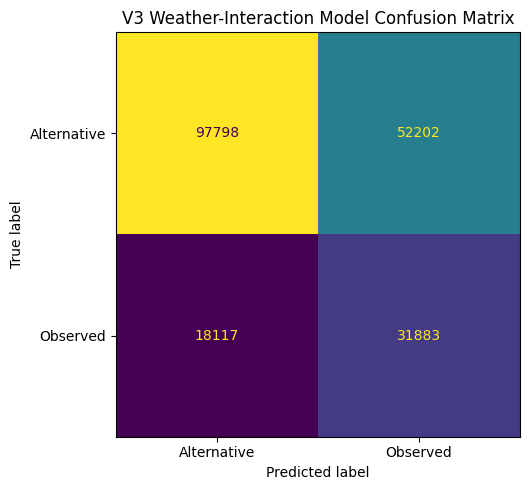

In [13]:
# a figure and axis for the confusion matrix plot
fig, ax = plt.subplots(figsize=(6, 5))

# Generate and display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    test_df[TARGET],          # Actual class labels
    weather_pred,             # Predicted class labels

    # Labels to display for each class
    display_labels=["Alternative", "Observed"],

    # Draw the plot on the created axis
    ax=ax,

    # Do not display a colour scale
    colorbar=False,
)

# Add a title to the figure
ax.set_title("V3 Weather-Interaction Model Confusion Matrix")

# Adjust the layout to prevent overlapping labels
plt.tight_layout()

# Save the figure as a high-quality PNG image
plt.savefig(
    FIGURE_DIR / "v3_confusion_matrix.png",
    dpi=300
)

# Display the confusion matrix
plt.show()

<Figure size 700x600 with 0 Axes>

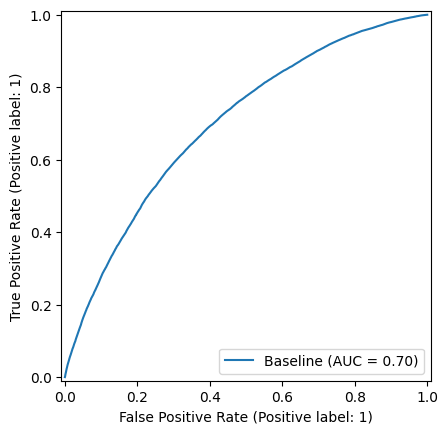

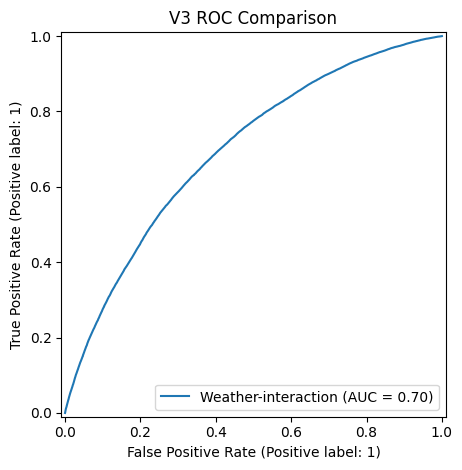

In [14]:
# Create a figure for the ROC curve comparison
plt.figure(figsize=(7, 6))

# Plot the ROC curve for the baseline model
RocCurveDisplay.from_predictions(
    test_df[TARGET],      # Actual class labels
    baseline_prob,        # Predicted probabilities from the baseline model
    name="Baseline"       # Label shown in the legend
)

# Plot the ROC curve for the weather-interaction model
RocCurveDisplay.from_predictions(
    test_df[TARGET],      # Actual class labels
    weather_prob,         # Predicted probabilities from the weather model
    name="Weather-interaction"  # Label shown in the legend
)

# Add a title to the comparison plot
plt.title("V3 ROC Comparison")

# Adjust the layout to prevent overlapping labels
plt.tight_layout()

# Save the figure as a high-quality PNG image
plt.savefig(
    FIGURE_DIR / "v3_roc_comparison.png",
    dpi=300
)

# Display the ROC comparison plot
plt.show()

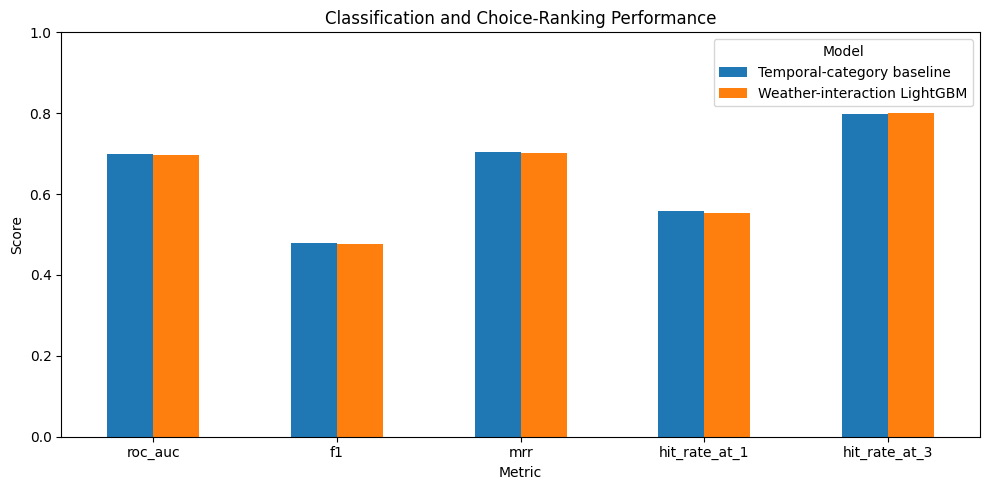

In [15]:
# Select the evaluation metrics to compare between the two models
selected_metrics = metrics_df.set_index("model")[[
    "roc_auc",
    "f1",
    "mrr",
    "hit_rate_at_1",
    "hit_rate_at_3"
]]

# Create a figure for the comparison chart
plt.figure(figsize=(10, 5))

# Plot a grouped bar chart of the selected metrics
selected_metrics.T.plot(
    kind="bar",
    ax=plt.gca()   # Draw the chart on the current axes
)

# Add a title to the chart
plt.title("Classification and Choice-Ranking Performance")

# Label the x-axis
plt.xlabel("Metric")

# Label the y-axis
plt.ylabel("Score")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Keep the metric names horizontal for better readability
plt.xticks(rotation=0)

# Display a legend showing the model names
plt.legend(title="Model")

# Adjust the layout to prevent overlapping labels
plt.tight_layout()

# Save the chart as a high-quality PNG image
plt.savefig(
    FIGURE_DIR / "v3_model_performance.png",
    dpi=300
)

# Display the chart
plt.show()

## 10. Permutation Importance

The importance test includes the explicit weather interactions. A positive value means that shuffling the feature reduces ROC-AUC.

,feature,importance_mean,importance_std
0,tourism_category,1.900265e-01,2.932410e-03
1,city,4.079080e-02,2.462175e-03
3,local_hour,2.988412e-02,1.166104e-03
2,time_period,5.875180e-03,3.745937e-04
4,day_of_week,3.925605e-03,1.064394e-03
24,humidity_x_outdoor,3.133256e-03,3.272213e-04
23,wind_x_outdoor,1.022973e-03,1.839362e-04
10,relative_humidity_2m,7.960999e-04,2.983636e-04
27,cloud_x_outdoor,5.460731e-04,1.459435e-04
18,thermal_discomfort,3.380156e-04,2.455504e-04


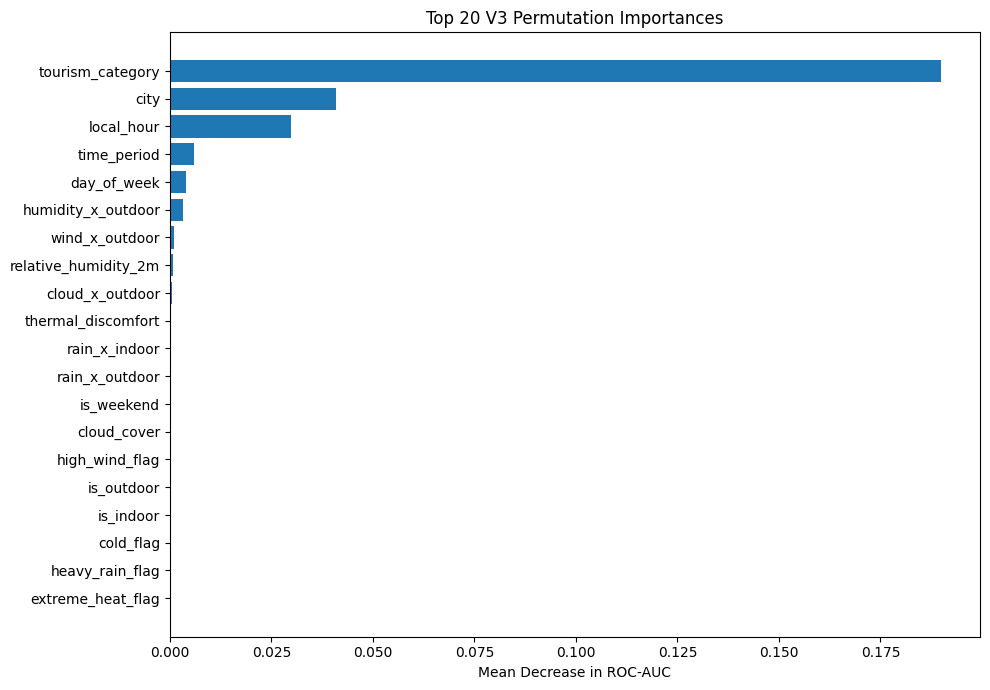

In [16]:
# Select the number of samples to use for permutation importance
# Use all rows if there are fewer than 15,000 observations
IMPORTANCE_SAMPLE = min(15_000, len(test_df))

# Randomly select a sample from the test dataset
importance_sample = test_df.sample(
    IMPORTANCE_SAMPLE,
    random_state=SEED
)

# Calculate permutation feature importance
perm = permutation_importance(
    weather_model,                              # Trained weather-interaction model
    importance_sample[WEATHER_MODEL_FEATURES],  # Input features
    importance_sample[TARGET],                  # True labels

    # Evaluate feature importance using ROC-AUC
    scoring="roc_auc",

    # Repeat the process three times for more reliable results
    n_repeats=3,

    # Set a random seed for reproducibility
    random_state=SEED,

    # Use all available CPU cores
    n_jobs=-1,
)

# Store the feature importance results in a DataFrame
importance_df = pd.DataFrame({
    "feature": WEATHER_MODEL_FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})

# Sort the features from most important to least important
importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

# Display the top 25 most important features
display(importance_df.head(25))

# Save the feature importance values to a CSV file
importance_df.to_csv(
    RESULT_DIR / "v3_permutation_importance.csv",
    index=False
)

# Select the top 20 features for plotting
plot_df = importance_df.head(20).sort_values("importance_mean")

# Create a horizontal bar chart
plt.figure(figsize=(10, 7))
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"]
)

# Add a title and axis label
plt.title("Top 20 V3 Permutation Importances")
plt.xlabel("Mean Decrease in ROC-AUC")

# Adjust the layout
plt.tight_layout()

# Save the figure as a high-quality PNG image
plt.savefig(
    FIGURE_DIR / "v3_permutation_importance.png",
    dpi=300
)

# Display the chart
plt.show()

## 11. Transparent domain-informed weather comfort score

The empirical model learns from historical check-ins. The rule layer captures safety and comfort knowledge needed for itinerary planning.

This layer is transparent and must be reported as a decision-support rule component, not as a purely learned behavioural model.

In [17]:
# Function to keep a value between a minimum and maximum range
def clamp(value, low=0.0, high=1.0):
    return max(low, min(high, value))

# Function to calculate a weather suitability score for each tourism category
def domain_weather_score(category, weather):

    # Extract weather values
    temperature = float(weather["temperature_2m"])
    precipitation = float(weather["precipitation"])
    wind = float(weather["wind_speed_10m"])
    humidity = float(weather["relative_humidity_2m"])
    cloud = float(weather["cloud_cover"])

    # Check whether the tourism category is outdoor or indoor
    outdoor = category in OUTDOOR_CATEGORIES

    # Calculate a temperature comfort score
    # The score is highest around 24°C
    temperature_score = clamp(1 - abs(temperature - 24) / 18)

    # Calculate scores differently for outdoor and indoor activities
    if outdoor:

        # Outdoor activities are more affected by weather
        rain_score = math.exp(-0.16 * precipitation)
        wind_score = clamp(1 - max(0, wind - 15) / 35)
        humidity_score = clamp(1 - max(0, humidity - 80) / 35)
        cloud_score = clamp(1 - max(0, cloud - 85) / 100)

        # Combine the weather scores using weighted averages
        score = (
            0.35 * rain_score +
            0.20 * wind_score +
            0.20 * temperature_score +
            0.15 * humidity_score +
            0.10 * cloud_score
        )

    else:

        # Indoor activities are less affected by rain and heat
        rain_bonus = clamp(0.65 + precipitation / 30)
        heat_resilience = clamp(0.75 + max(0, temperature - 30) / 30)

        # Calculate the overall indoor suitability score
        score = (
            0.45 * rain_bonus +
            0.25 * heat_resilience +
            0.20 * temperature_score +
            0.10 * 0.80
        )

    # Ensure the final score is between 0 and 1
    return clamp(score)

# Define different weather scenarios for testing
WEATHER_SCENARIOS = {
    "clear_mild": {
        "temperature_2m": 27.0,
        "precipitation": 0.0,
        "cloud_cover": 20.0,
        "relative_humidity_2m": 65.0,
        "wind_speed_10m": 10.0,
    },
    "hot_sunny": {
        "temperature_2m": 34.0,
        "precipitation": 0.0,
        "cloud_cover": 10.0,
        "relative_humidity_2m": 72.0,
        "wind_speed_10m": 8.0,
    },
    "overcast": {
        "temperature_2m": 27.0,
        "precipitation": 0.0,
        "cloud_cover": 92.0,
        "relative_humidity_2m": 80.0,
        "wind_speed_10m": 12.0,
    },
    "light_rain": {
        "temperature_2m": 25.0,
        "precipitation": 2.0,
        "cloud_cover": 95.0,
        "relative_humidity_2m": 88.0,
        "wind_speed_10m": 15.0,
    },
    "heavy_rain": {
        "temperature_2m": 24.0,
        "precipitation": 15.0,
        "cloud_cover": 100.0,
        "relative_humidity_2m": 95.0,
        "wind_speed_10m": 28.0,
    },
}

# Store the calculated scores
domain_table = []

# Calculate a weather suitability score for every
# tourism category under every weather scenario
for scenario, weather in WEATHER_SCENARIOS.items():
    for category in MODEL_CATEGORIES:
        domain_table.append({
            "scenario": scenario,
            "tourism_category": category,
            "domain_weather_score": domain_weather_score(category, weather),
        })

# Convert the results into a DataFrame
domain_table = pd.DataFrame(domain_table)

# Display the results as a pivot table
display(
    domain_table.pivot(
        index="tourism_category",
        columns="scenario",
        values="domain_weather_score"
    ).round(3)
)

# Save the scores to a CSV file
domain_table.to_csv(
    RESULT_DIR / "v3_domain_weather_scores.csv",
    index=False
)

scenario,clear_mild,heavy_rain,hot_sunny,light_rain,overcast
tourism_category,,,,,
accommodation,0.727,0.918,0.682,0.779,0.727
indoor_cultural,0.727,0.918,0.682,0.779,0.727
indoor_entertainment,0.727,0.918,0.682,0.779,0.727
indoor_food,0.727,0.918,0.682,0.779,0.727
indoor_shopping,0.727,0.918,0.682,0.779,0.727
outdoor_cultural,0.967,0.528,0.889,0.849,0.960
outdoor_nature,0.967,0.528,0.889,0.849,0.960


## 12. Hybrid empirical-domain suitability

Default blend:
- 65% empirical LightGBM probability
- 35% transparent weather comfort score

The weights can be tested in sensitivity analysis.

In [18]:
# Function to create model input data for different tourism categories
def model_input_for_categories(categories, weather, local_hour=10, month=7):

    # Create a DataFrame containing the required input features
    df = pd.DataFrame({
        "tourism_category": categories,
        "city": "Tokyo",                    # Example city
        "time_period": time_period(local_hour),
        "local_hour": local_hour,
        "day_of_week": 5,                   # Saturday
        "is_weekend": 1,
        "month": month,

        # Add the weather variables
        **{key: value for key, value in weather.items()},
    })

    # Create the interaction features used by the model
    return add_interaction_features(df)

# Function to combine machine learning predictions with domain knowledge
def hybrid_category_scores(
    categories,
    scenario_name,
    model_weight=0.65,
    domain_weight=0.35,
    local_hour=10,
    month=7,
):

    # Select the chosen weather scenario
    weather = WEATHER_SCENARIOS[scenario_name]

    # Prepare the input data for the machine learning model
    model_input = model_input_for_categories(
        categories,
        weather,
        local_hour=local_hour,
        month=month
    )

    # Predict the probability of each tourism category
    empirical = weather_model.predict_proba(
        model_input[WEATHER_MODEL_FEATURES]
    )[:, 1]

    # Calculate the domain-based weather suitability scores
    domain = np.array([
        domain_weather_score(category, weather)
        for category in categories
    ])

    # Combine the machine learning score and domain score
    hybrid = (
        model_weight * empirical +
        domain_weight * domain
    )

    # Return all scores in a DataFrame
    return pd.DataFrame({
        "tourism_category": categories,
        "empirical_score": empirical,
        "domain_score": domain,
        "hybrid_score": hybrid,
    })

# Store the results for all weather scenarios
hybrid_lookup_frames = []

# Calculate hybrid scores for every weather scenario
for scenario in WEATHER_SCENARIOS:

    frame = hybrid_category_scores(
        MODEL_CATEGORIES,
        scenario
    )

    # Add the scenario name
    frame["scenario"] = scenario

    hybrid_lookup_frames.append(frame)

# Combine all results into one DataFrame
hybrid_lookup = pd.concat(
    hybrid_lookup_frames,
    ignore_index=True
)

# Display the hybrid scores as a pivot table
display(
    hybrid_lookup.pivot(
        index="tourism_category",
        columns="scenario",
        values="hybrid_score"
    ).round(3)
)

# Save the lookup table as a CSV file
hybrid_lookup.to_csv(
    RESULT_DIR / "v3_hybrid_suitability_lookup.csv",
    index=False
)

scenario,clear_mild,heavy_rain,hot_sunny,light_rain,overcast
tourism_category,,,,,
accommodation,0.528,0.551,0.495,0.533,0.501
indoor_cultural,0.545,0.670,0.532,0.561,0.544
indoor_entertainment,0.518,0.566,0.505,0.537,0.518
indoor_food,0.537,0.606,0.518,0.575,0.535
indoor_shopping,0.613,0.647,0.605,0.644,0.614
outdoor_cultural,0.722,0.509,0.701,0.600,0.721
outdoor_nature,0.687,0.444,0.666,0.554,0.682


## 13. Weather sensitivity analysis
This test verifies that the final decision score reacts plausibly to changing weather.

Expected behaviour:

Outdoor categories should decline from clear weather to heavy rain.
Indoor categories should remain stable or become relatively more attractive.

,tourism_category,clear_score,heavy_rain_score,score_change,category_environment
0,outdoor_nature,0.6874,0.4443,-0.2431,outdoor
1,outdoor_cultural,0.7217,0.5093,-0.2125,outdoor
2,indoor_cultural,0.5451,0.6698,0.1248,indoor
3,indoor_food,0.5366,0.6058,0.0692,indoor
4,indoor_shopping,0.6135,0.6472,0.0337,indoor
5,indoor_entertainment,0.5184,0.5662,0.0478,indoor
6,accommodation,0.5280,0.5509,0.0229,indoor


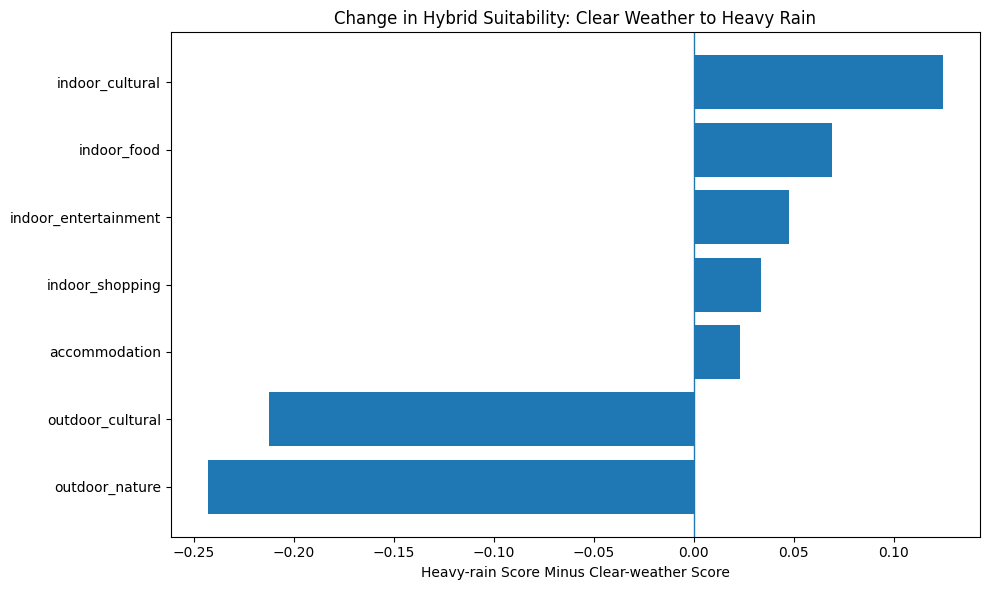

In [19]:
# Store the weather sensitivity results
sensitivity_rows = []

# Compare each tourism category under clear weather and heavy rain
for category in MODEL_CATEGORIES:

    # Get the hybrid suitability score for clear weather
    clear_score = hybrid_lookup.query(
        "scenario == 'clear_mild' and tourism_category == @category"
    )["hybrid_score"].iloc[0]

    # Get the hybrid suitability score for heavy rain
    rain_score = hybrid_lookup.query(
        "scenario == 'heavy_rain' and tourism_category == @category"
    )["hybrid_score"].iloc[0]

    # Calculate how much the score changes
    sensitivity_rows.append({
        "tourism_category": category,
        "clear_score": clear_score,
        "heavy_rain_score": rain_score,

        # Positive = score increased, Negative = score decreased
        "score_change": rain_score - clear_score,

        # Label the category as indoor or outdoor
        "category_environment": (
            "outdoor"
            if category in OUTDOOR_CATEGORIES
            else "indoor"
        ),
    })

# Convert the results into a DataFrame
sensitivity_df = pd.DataFrame(sensitivity_rows)

# Display the weather sensitivity table
display(sensitivity_df.round(4))

# Save the results as a CSV file
sensitivity_df.to_csv(
    RESULT_DIR / "v3_weather_sensitivity_analysis.csv",
    index=False
)

# Sort the data by the amount of score change
plot_data = sensitivity_df.sort_values("score_change")

# Create a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["tourism_category"],
    plot_data["score_change"]
)

# Draw a vertical reference line at zero
plt.axvline(0, linewidth=1)

# Add chart title and axis label
plt.title("Change in Hybrid Suitability: Clear Weather to Heavy Rain")
plt.xlabel("Heavy-rain Score Minus Clear-weather Score")

# Adjust the layout
plt.tight_layout()

# Save the chart as a high-quality PNG image
plt.savefig(
    FIGURE_DIR / "v3_weather_sensitivity.png",
    dpi=300
)

# Display the chart
plt.show()

## 14. Sri Lankan POI dataset

In [20]:
from pathlib import Path
import pandas as pd

# Point this at wherever you save the CSV — e.g. inside your existing DATA_DIR
# csv_path = DATA_DIR / "sri_lanka_pois_v4_100.csv"
csv_path = "sri_lanka_pois_v4_100.csv"

sri_lanka_pois = pd.read_csv(csv_path)

print(f"Loaded {len(sri_lanka_pois)} POIs across {sri_lanka_pois['city'].nunique()} cities")
display(sri_lanka_pois.head())

Loaded 105 POIs across 35 cities


,poi_id,name,city,latitude,longitude,tourism_category,opening_time,closing_time,visit_duration_minutes,popularity_score,indoor_outdoor
0,SL001,Sigiriya Rock Fortress,Sigiriya,7.9570,80.7603,outdoor_cultural,07:00,17:30,180,0.98,outdoor
1,SL002,Pidurangala Rock,Sigiriya,7.9652,80.7611,outdoor_nature,05:00,18:00,150,0.87,outdoor
2,SL003,Sigiriya Museum,Sigiriya,7.9530,80.7580,indoor_cultural,08:00,17:00,60,0.72,indoor
3,SL004,Dambulla Cave Temple,Dambulla,7.8567,80.6492,indoor_cultural,07:00,19:00,120,0.92,mixed
4,SL005,Polonnaruwa Ancient City,Polonnaruwa,7.9403,81.0188,outdoor_cultural,07:00,18:00,210,0.94,outdoor


## 15. Weather risk index and scenario-adaptive policy

The risk index combines precipitation, wind, humidity, cloud cover, and thermal discomfort.  
It is normalized to the range 0–1.

The policy maps weather severity to:
- ranking weights,
- outdoor score penalties,
- minimum suitability,
- maximum outdoor stops,
- maximum outdoor exposure.

In [21]:
# Function to normalise a value between 0 and 1
def normalize_clip(value, low, high):

    # Avoid division by zero
    if high <= low:
        return 0.0

    # Scale the value and keep it within the range 0–1
    return float(np.clip((value - low) / (high - low), 0, 1))

# Function to calculate an overall weather risk score
def weather_risk_index(weather):

    # Calculate the risk contribution of each weather variable
    precipitation_risk = normalize_clip(
        float(weather["precipitation"]), 0, 15
    )

    wind_risk = normalize_clip(
        float(weather["wind_speed_10m"]), 10, 35
    )

    humidity_risk = normalize_clip(
        float(weather["relative_humidity_2m"]), 70, 100
    )

    cloud_risk = normalize_clip(
        float(weather["cloud_cover"]), 70, 100
    )

    # Measure how far the temperature is from the ideal 24°C
    thermal_risk = normalize_clip(
        abs(float(weather["temperature_2m"]) - 24),
        5,
        15
    )

    # Combine the individual risks using weighted averages
    risk = (
        0.45 * precipitation_risk +
        0.20 * wind_risk +
        0.15 * humidity_risk +
        0.10 * cloud_risk +
        0.10 * thermal_risk
    )

    # Return the final risk score between 0 and 1
    return float(np.clip(risk, 0, 1))

# Function to create recommendation policies based on weather risk
def dynamic_policy(scenario_name):

    # Get the weather values for the selected scenario
    weather = WEATHER_SCENARIOS[scenario_name]

    # Calculate the weather risk index
    risk = weather_risk_index(weather)

    # Define recommendation rules for low-risk weather
    if risk < 0.25:
        severity = "low"
        policy = {
            "weather_weight": 0.50,
            "preference_weight": 0.22,
            "popularity_weight": 0.18,
            "distance_weight": 0.10,
            "outdoor_multiplier": 1.00,
            "minimum_suitability": 0.25,
            "max_outdoor_stops": 6,
            "max_outdoor_exposure_minutes": 600,
        }

    # Define recommendation rules for moderate-risk weather
    elif risk < 0.55:
        severity = "moderate"
        policy = {
            "weather_weight": 0.62,
            "preference_weight": 0.17,
            "popularity_weight": 0.14,
            "distance_weight": 0.07,
            "outdoor_multiplier": 0.62,
            "minimum_suitability": 0.34,
            "max_outdoor_stops": 2,
            "max_outdoor_exposure_minutes": 150,
        }

    # Define recommendation rules for high-risk weather
    else:
        severity = "high"
        policy = {
            "weather_weight": 0.72,
            "preference_weight": 0.13,
            "popularity_weight": 0.10,
            "distance_weight": 0.05,
            "outdoor_multiplier": 0.15,
            "minimum_suitability": 0.45,
            "max_outdoor_stops": 0,
            "max_outdoor_exposure_minutes": 0,
        }

    # Add additional information to the policy
    policy["risk_index"] = risk
    policy["severity"] = severity
    policy["scenario_name"] = scenario_name

    return policy

# Create a policy table for every weather scenario
policy_table = pd.DataFrame([
    dynamic_policy(name)
    for name in WEATHER_SCENARIOS
])

# Display the policy table
display(policy_table)

# Save the policy table as a CSV file
policy_table.to_csv(
    RESULT_DIR / "v4_weather_policy_table.csv",
    index=False
)

,weather_weight,preference_weight,popularity_weight,distance_weight,outdoor_multiplier,minimum_suitability,max_outdoor_stops,max_outdoor_exposure_minutes,risk_index,severity,scenario_name
0,0.50,0.22,0.18,0.10,1.00,0.25,6,600,0.000000,low,clear_mild
1,0.50,0.22,0.18,0.10,1.00,0.25,6,600,0.060000,low,hot_sunny
2,0.50,0.22,0.18,0.10,1.00,0.25,6,600,0.139333,low,overcast
3,0.62,0.17,0.14,0.07,0.62,0.34,2,150,0.273333,moderate,light_rain
4,0.72,0.13,0.10,0.05,0.15,0.45,0,0,0.819000,high,heavy_rain


## 16. Risk-aware POI ranking

The final score remains interpretable:

`weather + preference + popularity + distance`

For outdoor POIs, the score is additionally multiplied by a severity-dependent penalty.  
The unpenalized score is retained for auditing.

In [22]:
# Function to rank tourist attractions using the V4 recommendation model
def rank_pois_v4(
    pois,
    start_lat,
    start_lon,
    preferred_categories,
    scenario_name,
):

    # Get the recommendation policy for the selected weather scenario
    policy = dynamic_policy(scenario_name)

    # Create a copy of the POI dataset
    ranked = pois.copy()

    # Get the tourism categories of all attractions
    categories = ranked["tourism_category"].tolist()

    # Calculate the empirical, domain, and hybrid weather scores
    scores = hybrid_category_scores(categories, scenario_name)

    ranked["empirical_score"] = scores["empirical_score"].to_numpy()
    ranked["domain_score"] = scores["domain_score"].to_numpy()
    ranked["weather_suitability"] = scores["hybrid_score"].to_numpy()

    # Give a score of 1 if the attraction matches the user's preferences
    ranked["preference_score"] = ranked["tourism_category"].isin(
        preferred_categories
    ).astype(float)

    # Calculate the distance from the user's starting location
    ranked["distance_km"] = ranked.apply(
        lambda row: haversine_km(
            start_lat,
            start_lon,
            row["latitude"],
            row["longitude"],
        ),
        axis=1,
    )

    # Convert distance into a score between 0 and 1
    max_distance = max(ranked["distance_km"].max(), 1e-6)
    ranked["distance_score"] = (
        1 - ranked["distance_km"] / max_distance
    )

    # Calculate the initial ranking score using weighted factors
    ranked["base_ranking_score"] = (
        policy["weather_weight"] * ranked["weather_suitability"] +
        policy["preference_weight"] * ranked["preference_score"] +
        policy["popularity_weight"] * ranked["popularity_score"] +
        policy["distance_weight"] * ranked["distance_score"]
    )

    # Identify outdoor attractions
    outdoor_mask = ranked["indoor_outdoor"].eq("outdoor")

    # Start with no penalty
    ranked["risk_penalty_multiplier"] = 1.0

    # Remove outdoor attractions completely during severe weather
    if policy["max_outdoor_stops"] == 0:
        ranked.loc[
            outdoor_mask,
            "risk_penalty_multiplier"
        ] = 0.0

    # Otherwise reduce their ranking according to the weather policy
    else:
        ranked.loc[
            outdoor_mask,
            "risk_penalty_multiplier"
        ] = policy["outdoor_multiplier"]

    # Apply the weather penalty to the ranking score
    ranked["ranking_score"] = (
        ranked["base_ranking_score"] *
        ranked["risk_penalty_multiplier"]
    )

    # Store the current weather information
    ranked["weather_risk_index"] = policy["risk_index"]
    ranked["weather_severity"] = policy["severity"]

    # Return the attractions ranked from highest to lowest score
    return ranked.sort_values(
        [
            "ranking_score",
            "weather_suitability",
            "popularity_score",
        ],
        ascending=False,
    ).reset_index(drop=True)

## 17. Constraint-aware greedy insertion planner

The planner rejects a trial route when it exceeds:
- the maximum number of outdoor stops,
- the maximum number of outdoor exposure minutes,
- opening hours,
- the daily time budget.

This makes the route genuinely responsive to unsafe or uncomfortable conditions.

In [23]:
# Convert a time in HH:MM format into total minutes
def time_to_minutes(value):
    hour, minute = map(int, value.split(":"))
    return hour * 60 + minute

# Convert total minutes back into HH:MM format
def minutes_to_time(value):
    value = int(round(value))
    return f"{value // 60:02d}:{value % 60:02d}"

# Estimate travel time between two locations
def estimated_travel_minutes(
    lat1,
    lon1,
    lat2,
    lon2,
    average_speed_kmh=28,
    road_factor=1.30,
):
    # Calculate road distance using the Haversine distance
    distance = haversine_km(lat1, lon1, lat2, lon2) * road_factor

    # Convert distance into travel time (minimum 5 minutes)
    return max(5, int(round(distance / average_speed_kmh * 60)))

# Simulate travelling through a complete itinerary
def simulate_route_v4(
    route,
    start_lat,
    start_lon,
    day_start_minutes,
    day_end_minutes,
    max_outdoor_stops,
    max_outdoor_exposure_minutes,
):

    # Initialise the current location and time
    current_lat, current_lon = start_lat, start_lon
    current_time = day_start_minutes

    schedule = []
    total_travel = 0
    outdoor_stops = 0
    outdoor_exposure = 0

    # Visit each attraction in the route
    for poi in route:

        # Check whether the attraction is outdoors
        is_outdoor = poi["indoor_outdoor"] == "outdoor"

        # Track outdoor visits
        if is_outdoor:
            outdoor_stops += 1
            outdoor_exposure += int(poi["visit_duration_minutes"])

        # Stop if outdoor limits are exceeded
        if outdoor_stops > max_outdoor_stops:
            return None

        if outdoor_exposure > max_outdoor_exposure_minutes:
            return None

        # Estimate travel time to the next attraction
        travel = estimated_travel_minutes(
            current_lat,
            current_lon,
            poi["latitude"],
            poi["longitude"],
        )

        arrival = current_time + travel

        # Get opening and closing times
        opening = time_to_minutes(poi["opening_time"])
        closing = time_to_minutes(poi["closing_time"])

        # Wait if arriving before opening time
        visit_start = max(arrival, opening)

        # Calculate departure time
        departure = visit_start + int(poi["visit_duration_minutes"])

        # Reject routes that exceed opening hours or day limits
        if departure > closing or departure > day_end_minutes:
            return None

        # Save the visit details
        schedule.append({
            "poi_id": poi["poi_id"],
            "name": poi["name"],
            "tourism_category": poi["tourism_category"],
            "indoor_outdoor": poi["indoor_outdoor"],
            "arrival": minutes_to_time(arrival),
            "visit_start": minutes_to_time(visit_start),
            "departure": minutes_to_time(departure),
            "travel_minutes": travel,
            "visit_duration_minutes": int(poi["visit_duration_minutes"]),
            "weather_suitability": float(poi["weather_suitability"]),
            "base_ranking_score": float(poi["base_ranking_score"]),
            "risk_penalty_multiplier": float(poi["risk_penalty_multiplier"]),
            "ranking_score": float(poi["ranking_score"]),
            "latitude": float(poi["latitude"]),
            "longitude": float(poi["longitude"]),
        })

        # Update totals and current position
        total_travel += travel
        current_time = departure
        current_lat, current_lon = poi["latitude"], poi["longitude"]

    # Return the completed itinerary
    return {
        "schedule": schedule,
        "finish_minutes": current_time,
        "total_travel_minutes": total_travel,
        "total_utility": sum(item["ranking_score"] for item in schedule),
        "outdoor_stops": outdoor_stops,
        "outdoor_exposure_minutes": outdoor_exposure,
    }

# Build the best itinerary using a constrained greedy search
def constrained_greedy_itinerary(
    ranked_pois,
    start_lat,
    start_lon,
    policy,
    day_start="08:00",
    day_end="18:30",
    max_stops=6,
):

    # Keep only attractions that meet the minimum weather suitability
    candidates = ranked_pois[
        ranked_pois["weather_suitability"] >= policy["minimum_suitability"]
    ].to_dict("records")

    route = []

    # Simulate an empty itinerary
    current_best = simulate_route_v4(
        route,
        start_lat,
        start_lon,
        time_to_minutes(day_start),
        time_to_minutes(day_end),
        policy["max_outdoor_stops"],
        policy["max_outdoor_exposure_minutes"],
    )

    # Keep adding attractions until no more can be added
    while candidates and len(route) < max_stops:

        best_option = None

        # Test every remaining attraction
        for candidate in candidates:

            # Try inserting the attraction at every position
            for position in range(len(route) + 1):

                trial_route = (
                    route[:position] +
                    [candidate] +
                    route[position:]
                )

                # Simulate the new route
                simulation = simulate_route_v4(
                    trial_route,
                    start_lat,
                    start_lon,
                    time_to_minutes(day_start),
                    time_to_minutes(day_end),
                    policy["max_outdoor_stops"],
                    policy["max_outdoor_exposure_minutes"],
                )

                # Skip invalid routes
                if simulation is None:
                    continue

                # Calculate the increase in total ranking score
                utility_gain = (
                    simulation["total_utility"] -
                    current_best["total_utility"]
                )

                # Calculate how much extra time is required
                added_duration = max(
                    simulation["finish_minutes"] -
                    current_best["finish_minutes"],
                    1,
                )

                # Measure the benefit gained per minute
                efficiency = utility_gain / added_duration

                # Calculate the average weather suitability
                mean_suitability = (
                    np.mean([
                        item["weather_suitability"]
                        for item in simulation["schedule"]
                    ])
                    if simulation["schedule"] else 0
                )

                option = {
                    "route": trial_route,
                    "simulation": simulation,
                    "efficiency": efficiency,
                    "mean_suitability": mean_suitability,
                    "candidate_id": candidate["poi_id"],
                }

                # Keep the best route found so far
                if best_option is None:
                    best_option = option

                elif option["efficiency"] > best_option["efficiency"] + 1e-9:
                    best_option = option

                # If efficiency is equal, choose the safer itinerary
                elif (
                    abs(option["efficiency"] - best_option["efficiency"]) <= 1e-9
                    and option["mean_suitability"] >
                    best_option["mean_suitability"]
                ):
                    best_option = option

        # Stop if no valid route exists
        if best_option is None:
            break

        # Update the current best itinerary
        route = best_option["route"]
        current_best = best_option["simulation"]

        # Remove the selected attraction from future consideration
        candidates = [
            candidate
            for candidate in candidates
            if candidate["poi_id"] != best_option["candidate_id"]
        ]

    # Return the completed itinerary
    return current_best

## 18. Generate scenario-specific Kandy itineraries

In [24]:
# Function to calculate the distance between two geographical coordinates
# using the Haversine formula
def haversine_km(lat1, lon1, lat2, lon2):

    # Earth's radius in kilometres
    R = 6371

    # Convert latitude and longitude values from degrees to radians
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    # Calculate the difference between coordinates
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    # Apply the Haversine formula
    a = (
        math.sin(dlat / 2)**2 +
        math.cos(lat1_rad) *
        math.cos(lat2_rad) *
        math.sin(dlon / 2)**2
    )

    c = 2 * math.atan2(
        math.sqrt(a),
        math.sqrt(1 - a)
    )

    # Calculate the final distance in kilometres
    distance = R * c

    return distance


# Define the starting location in Kandy
# Latitude and longitude coordinates
KANDY_START = (7.2906, 80.6337)

# Select only points of interest located in Kandy
kandy_pois = sri_lanka_pois[
    sri_lanka_pois["city"] == "Kandy"
].copy()

# Define user tourism preferences
preferences = [
    "outdoor_nature",
    "indoor_cultural",
    "indoor_entertainment",
]

# Store generated itineraries and rankings for each weather scenario
scenario_itineraries = {}
scenario_rankings = {}

# Generate recommendations for every weather scenario
for scenario_name in WEATHER_SCENARIOS:

    # Get the dynamic policy for the current weather condition
    policy = dynamic_policy(scenario_name)

    # Rank all available attractions based on:
    # weather suitability, preferences, popularity, and distance
    ranked = rank_pois_v4(
        kandy_pois,
        KANDY_START[0],
        KANDY_START[1],
        preferences,
        scenario_name,
    )

    # Generate an optimised itinerary using the ranked attractions
    itinerary = constrained_greedy_itinerary(
        ranked,
        KANDY_START[0],
        KANDY_START[1],
        policy,
    )

    # Store ranking and itinerary results
    scenario_rankings[scenario_name] = ranked
    scenario_itineraries[scenario_name] = itinerary

    # Convert the generated schedule into a DataFrame
    schedule = pd.DataFrame(
        itinerary["schedule"]
    )

    # Save the itinerary for this weather scenario
    schedule.to_csv(
        RESULT_DIR / f"v4_kandy_{scenario_name}_itinerary.csv",
        index=False,
    )

    # Display the results
    print("\nSCENARIO:", scenario_name)

    print("POLICY:", policy)

    # Check whether a valid itinerary was generated
    if schedule.empty:
        print("No feasible itinerary.")

    else:

        # Display key itinerary information
        display(
            schedule[[
                "name",
                "tourism_category",
                "indoor_outdoor",
                "visit_start",
                "departure",
                "weather_suitability",
                "risk_penalty_multiplier",
                "ranking_score",
            ]].round(3)
        )


SCENARIO: clear_mild
POLICY: {'weather_weight': 0.5, 'preference_weight': 0.22, 'popularity_weight': 0.18, 'distance_weight': 0.1, 'outdoor_multiplier': 1.0, 'minimum_suitability': 0.25, 'max_outdoor_stops': 6, 'max_outdoor_exposure_minutes': 600, 'risk_index': 0.0, 'severity': 'low', 'scenario_name': 'clear_mild'}


,name,tourism_category,indoor_outdoor,visit_start,departure,weather_suitability,risk_penalty_multiplier,ranking_score
0,The Empire Cafe Kandy,indoor_food,indoor,08:05,09:05,0.537,1.0,0.501
1,Kandy National Museum,indoor_cultural,indoor,09:10,10:40,0.545,1.0,0.724
2,Kandy Lake,outdoor_nature,outdoor,10:45,11:45,0.687,1.0,0.811
3,Kandy Muslim Hotel,indoor_food,indoor,11:50,12:35,0.537,1.0,0.496
4,Earl's Regency Hotel,accommodation,mixed,12:40,12:40,0.528,1.0,0.510
5,Ceylon Tea Museum,indoor_cultural,indoor,12:45,14:15,0.545,1.0,0.722



SCENARIO: hot_sunny
POLICY: {'weather_weight': 0.5, 'preference_weight': 0.22, 'popularity_weight': 0.18, 'distance_weight': 0.1, 'outdoor_multiplier': 1.0, 'minimum_suitability': 0.25, 'max_outdoor_stops': 6, 'max_outdoor_exposure_minutes': 600, 'risk_index': 0.060000000000000005, 'severity': 'low', 'scenario_name': 'hot_sunny'}


,name,tourism_category,indoor_outdoor,visit_start,departure,weather_suitability,risk_penalty_multiplier,ranking_score
0,The Empire Cafe Kandy,indoor_food,indoor,08:05,09:05,0.518,1.0,0.491
1,Kandy National Museum,indoor_cultural,indoor,09:10,10:40,0.532,1.0,0.717
2,Kandy Lake,outdoor_nature,outdoor,10:45,11:45,0.666,1.0,0.801
3,Kandy Muslim Hotel,indoor_food,indoor,11:50,12:35,0.518,1.0,0.486
4,Earl's Regency Hotel,accommodation,mixed,12:40,12:40,0.495,1.0,0.494
5,Ceylon Tea Museum,indoor_cultural,indoor,12:45,14:15,0.532,1.0,0.716



SCENARIO: overcast
POLICY: {'weather_weight': 0.5, 'preference_weight': 0.22, 'popularity_weight': 0.18, 'distance_weight': 0.1, 'outdoor_multiplier': 1.0, 'minimum_suitability': 0.25, 'max_outdoor_stops': 6, 'max_outdoor_exposure_minutes': 600, 'risk_index': 0.13933333333333334, 'severity': 'low', 'scenario_name': 'overcast'}


,name,tourism_category,indoor_outdoor,visit_start,departure,weather_suitability,risk_penalty_multiplier,ranking_score
0,The Empire Cafe Kandy,indoor_food,indoor,08:05,09:05,0.535,1.0,0.500
1,Kandy National Museum,indoor_cultural,indoor,09:10,10:40,0.544,1.0,0.723
2,Kandy Lake,outdoor_nature,outdoor,10:45,11:45,0.682,1.0,0.809
3,Kandy Muslim Hotel,indoor_food,indoor,11:50,12:35,0.535,1.0,0.495
4,Earl's Regency Hotel,accommodation,mixed,12:40,12:40,0.501,1.0,0.496
5,Ceylon Tea Museum,indoor_cultural,indoor,12:45,14:15,0.544,1.0,0.722



SCENARIO: light_rain
POLICY: {'weather_weight': 0.62, 'preference_weight': 0.17, 'popularity_weight': 0.14, 'distance_weight': 0.07, 'outdoor_multiplier': 0.62, 'minimum_suitability': 0.34, 'max_outdoor_stops': 2, 'max_outdoor_exposure_minutes': 150, 'risk_index': 0.2733333333333333, 'severity': 'moderate', 'scenario_name': 'light_rain'}


,name,tourism_category,indoor_outdoor,visit_start,departure,weather_suitability,risk_penalty_multiplier,ranking_score
0,World Buddhist Museum,indoor_cultural,indoor,08:05,09:35,0.561,1.0,0.687
1,The Empire Cafe Kandy,indoor_food,indoor,09:40,10:40,0.575,1.0,0.530
2,Kandy National Museum,indoor_cultural,indoor,10:45,12:15,0.561,1.0,0.690
3,Kandy Muslim Hotel,indoor_food,indoor,12:20,13:05,0.575,1.0,0.526
4,Earl's Regency Hotel,accommodation,mixed,13:10,13:10,0.533,1.0,0.515
5,Ceylon Tea Museum,indoor_cultural,indoor,13:15,14:45,0.561,1.0,0.689



SCENARIO: heavy_rain
POLICY: {'weather_weight': 0.72, 'preference_weight': 0.13, 'popularity_weight': 0.1, 'distance_weight': 0.05, 'outdoor_multiplier': 0.15, 'minimum_suitability': 0.45, 'max_outdoor_stops': 0, 'max_outdoor_exposure_minutes': 0, 'risk_index': 0.819, 'severity': 'high', 'scenario_name': 'heavy_rain'}


,name,tourism_category,indoor_outdoor,visit_start,departure,weather_suitability,risk_penalty_multiplier,ranking_score
0,World Buddhist Museum,indoor_cultural,indoor,08:05,09:35,0.670,1.0,0.733
1,The Empire Cafe Kandy,indoor_food,indoor,09:40,10:40,0.606,1.0,0.560
2,Kandy National Museum,indoor_cultural,indoor,10:45,12:15,0.670,1.0,0.735
3,Kandy Muslim Hotel,indoor_food,indoor,12:20,13:05,0.606,1.0,0.557
4,Earl's Regency Hotel,accommodation,mixed,13:10,13:10,0.551,1.0,0.528
5,Ceylon Tea Museum,indoor_cultural,indoor,13:15,14:45,0.670,1.0,0.735


## 19. Dynamic replanning evaluation

The clear-mild itinerary is treated as the original route.  
Each other scenario is compared against it.

In [25]:
# Function to create a summary of a generated itinerary
def itinerary_summary_v4(scenario_name, itinerary, policy):

    # Convert the itinerary schedule into a DataFrame
    schedule = pd.DataFrame(itinerary["schedule"])

    # Handle cases where no valid itinerary was generated
    if schedule.empty:
        return {
            "scenario": scenario_name,
            "risk_index": policy["risk_index"],
            "severity": policy["severity"],
            "number_of_stops": 0,
            "total_travel_minutes": 0,
            "finish_time": None,
            "total_utility": 0,
            "mean_weather_suitability": 0,
            "minimum_weather_suitability": 0,
            "outdoor_stops": 0,
            "outdoor_exposure_minutes": 0,
            "selected_places": "",
        }

    # Return summary statistics for a valid itinerary
    return {
        "scenario": scenario_name,
        "risk_index": policy["risk_index"],
        "severity": policy["severity"],

        # Number of attractions visited
        "number_of_stops": len(schedule),

        # Total travel time required
        "total_travel_minutes": itinerary["total_travel_minutes"],

        # Final completion time of the itinerary
        "finish_time": minutes_to_time(
            itinerary["finish_minutes"]
        ),

        # Total ranking utility score
        "total_utility": itinerary["total_utility"],

        # Average suitability of selected attractions
        "mean_weather_suitability": schedule[
            "weather_suitability"
        ].mean(),

        # Lowest suitability score among selected attractions
        "minimum_weather_suitability": schedule[
            "weather_suitability"
        ].min(),

        # Outdoor activity information
        "outdoor_stops": itinerary["outdoor_stops"],
        "outdoor_exposure_minutes": itinerary[
            "outdoor_exposure_minutes"
        ],

        # Create a readable route description
        "selected_places": " → ".join(
            schedule["name"]
        ),
    }


# Store summary results for all weather scenarios
summary_rows = []

# Generate an itinerary summary for each scenario
for scenario_name, itinerary in scenario_itineraries.items():

    summary_rows.append(
        itinerary_summary_v4(
            scenario_name,
            itinerary,
            dynamic_policy(scenario_name),
        )
    )

# Convert all summaries into a DataFrame
scenario_summary = pd.DataFrame(summary_rows)


# Use the clear weather route as the baseline comparison
clear_schedule = pd.DataFrame(
    scenario_itineraries["clear_mild"]["schedule"]
)

# Store the attraction IDs from the clear weather route
clear_ids = (
    set(clear_schedule["poi_id"])
    if not clear_schedule.empty
    else set()
)


# Store comparison results
comparison_rows = []


# Compare every scenario against the clear weather scenario
for _, row in scenario_summary.iterrows():

    scenario_name = row["scenario"]

    # Get the attractions selected in this scenario
    schedule = pd.DataFrame(
        scenario_itineraries[scenario_name]["schedule"]
    )

    scenario_ids = (
        set(schedule["poi_id"])
        if not schedule.empty
        else set()
    )

    # Calculate route similarity using Jaccard overlap
    union = clear_ids | scenario_ids

    overlap = (
        len(clear_ids & scenario_ids) / len(union)
        if union else 1.0
    )


    # Get the clear weather summary values
    clear_row = scenario_summary[
        scenario_summary["scenario"] == "clear_mild"
    ].iloc[0]


    # Store comparison metrics
    comparison_rows.append({
        **row.to_dict(),

        # Percentage similarity between routes
        "route_jaccard_overlap": overlap,

        # Percentage of route changes compared with clear weather
        "route_change_percentage": (1 - overlap) * 100,

        # Reduction in outdoor exposure time
        "outdoor_exposure_reduction_minutes": (
            clear_row["outdoor_exposure_minutes"] -
            row["outdoor_exposure_minutes"]
        ),

        # Percentage reduction in outdoor exposure
        "outdoor_exposure_reduction_percentage": (
            100 *
            (
                clear_row["outdoor_exposure_minutes"] -
                row["outdoor_exposure_minutes"]
            )
            /
            max(clear_row["outdoor_exposure_minutes"], 1)
        ),

        # Change in average weather suitability
        "mean_suitability_change": (
            row["mean_weather_suitability"] -
            clear_row["mean_weather_suitability"]
        ),

        # Difference in travel duration
        "travel_time_change_minutes": (
            row["total_travel_minutes"] -
            clear_row["total_travel_minutes"]
        ),

        # Percentage of utility maintained compared with clear weather
        "utility_retention_percentage": (
            100 *
            row["total_utility"] /
            max(clear_row["total_utility"], 1e-9)
        ),
    })


# Create final comparison DataFrame
dynamic_comparison = pd.DataFrame(comparison_rows)

# Display the comparison results
display(dynamic_comparison)


# Save scenario summaries
scenario_summary.to_csv(
    RESULT_DIR / "v4_scenario_itinerary_summary.csv",
    index=False,
)

# Save dynamic replanning comparison results
dynamic_comparison.to_csv(
    RESULT_DIR / "v4_dynamic_replanning_comparison.csv",
    index=False,
)

,scenario,risk_index,severity,number_of_stops,total_travel_minutes,finish_time,total_utility,mean_weather_suitability,minimum_weather_suitability,outdoor_stops,outdoor_exposure_minutes,selected_places,route_jaccard_overlap,route_change_percentage,outdoor_exposure_reduction_minutes,outdoor_exposure_reduction_percentage,mean_suitability_change,travel_time_change_minutes,utility_retention_percentage
0,clear_mild,0.000000,low,6,30,14:15,3.763814,0.563128,0.527982,1,60,The Empire Cafe Kandy → Kandy National Museum ...,1.000000,0.000000,0,0.0,0.000000,0,100.000000
1,hot_sunny,0.060000,low,6,30,14:15,3.704896,0.543489,0.494777,1,60,The Empire Cafe Kandy → Kandy National Museum ...,1.000000,0.000000,0,0.0,-0.019639,0,98.434627
2,overcast,0.139333,low,6,30,14:15,3.745488,0.557019,0.500616,1,60,The Empire Cafe Kandy → Kandy National Museum ...,1.000000,0.000000,0,0.0,-0.006109,0,99.513084
3,light_rain,0.273333,moderate,6,30,14:45,3.636395,0.560925,0.533245,0,0,World Buddhist Museum → The Empire Cafe Kandy ...,0.714286,28.571429,60,100.0,-0.002203,0,96.614635
4,heavy_rain,0.819000,high,6,30,14:45,3.848431,0.628646,0.550851,0,0,World Buddhist Museum → The Empire Cafe Kandy ...,0.714286,28.571429,60,100.0,0.065518,0,102.248168


## 20. Replanning visualizations

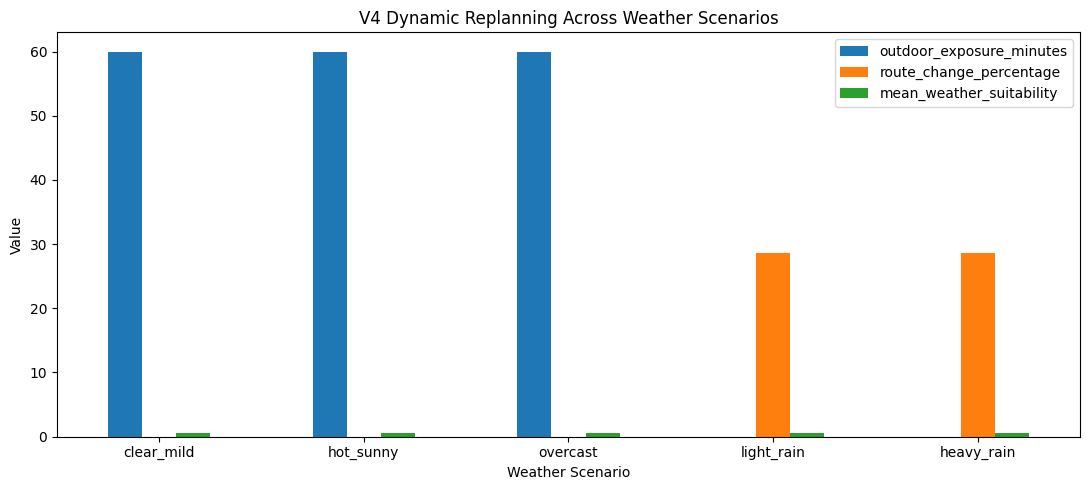

In [26]:
# Select important metrics from the scenario comparison results
# to visualise how the itinerary changes under different weather conditions
plot_df = dynamic_comparison.set_index("scenario")[[
    "outdoor_exposure_minutes",
    "route_change_percentage",
    "mean_weather_suitability",
]]

# Create a figure for the comparison chart
plt.figure(figsize=(11, 5))

# Generate a grouped bar chart comparing the selected metrics
plot_df.plot(
    kind="bar",
    ax=plt.gca()
)

# Add chart title and axis labels
plt.title(
    "V4 Dynamic Replanning Across Weather Scenarios"
)

plt.xlabel(
    "Weather Scenario"
)

plt.ylabel(
    "Value"
)

# Keep scenario labels horizontal for readability
plt.xticks(rotation=0)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Save the generated figure for reporting
plt.savefig(
    FIGURE_DIR / "v4_dynamic_replanning_scenarios.png",
    dpi=300,
)

# Display the plot
plt.show()

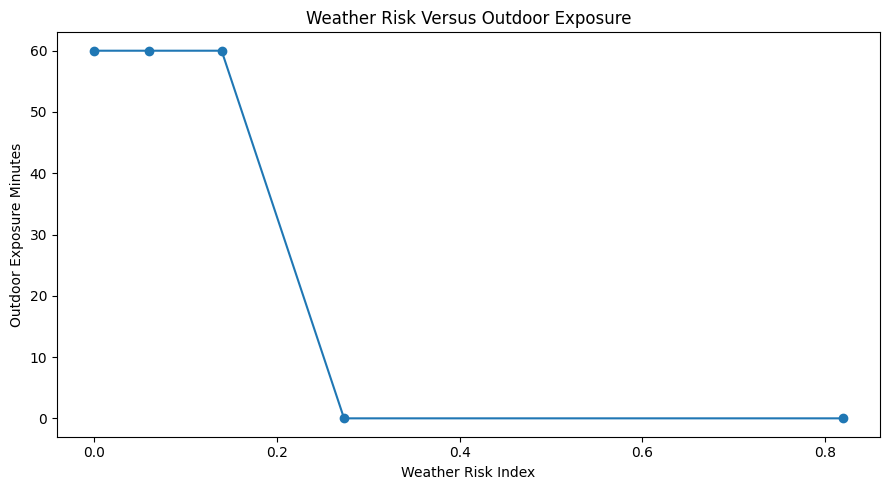

In [27]:
plt.figure(figsize=(9, 5))
plt.plot(
    dynamic_comparison["risk_index"],
    dynamic_comparison["outdoor_exposure_minutes"],
    marker="o",
)
plt.title("Weather Risk Versus Outdoor Exposure")
plt.xlabel("Weather Risk Index")
plt.ylabel("Outdoor Exposure Minutes")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "v4_risk_vs_outdoor_exposure.png",
    dpi=300,
)
plt.show()

## 21. Policy sensitivity analysis

This section verifies that replanning is not dependent on one unexplained penalty value.

The heavy-rain scenario is tested using multiple outdoor penalty multipliers and outdoor-stop limits.

In [28]:
# Select the heavy rain weather scenario
heavy_weather = WEATHER_SCENARIOS["heavy_rain"]

# Obtain the default policy settings for heavy rain
base_heavy_policy = dynamic_policy("heavy_rain")

# Store sensitivity analysis results
sensitivity_rows = []


# Test different outdoor activity penalty values
for outdoor_multiplier in [0.20, 0.28, 0.40, 0.55]:

    # Test different maximum allowed outdoor stops
    for max_outdoor_stops in [0, 1, 2]:

        # Create a copy of the original heavy rain policy
        test_policy = dict(base_heavy_policy)

        # Change the outdoor attraction penalty
        test_policy["outdoor_multiplier"] = outdoor_multiplier

        # Change the maximum number of outdoor attractions allowed
        test_policy["max_outdoor_stops"] = max_outdoor_stops

        # Set outdoor exposure limits based on allowed stops
        test_policy["max_outdoor_exposure_minutes"] = (
            0 if max_outdoor_stops == 0
            else 75 * max_outdoor_stops
        )


        # Rank attractions under heavy rain conditions
        ranked = rank_pois_v4(
            kandy_pois,
            KANDY_START[0],
            KANDY_START[1],
            preferences,
            "heavy_rain",
        )


        # Identify outdoor attractions
        outdoor_mask = ranked["indoor_outdoor"].eq("outdoor")


        # Apply the tested outdoor penalty multiplier
        ranked.loc[
            outdoor_mask,
            "risk_penalty_multiplier"
        ] = outdoor_multiplier


        # Recalculate ranking scores after applying the penalty
        ranked["ranking_score"] = (
            ranked["base_ranking_score"] *
            ranked["risk_penalty_multiplier"]
        )


        # Sort attractions based on the updated ranking score
        ranked = ranked.sort_values(
            "ranking_score",
            ascending=False,
        ).reset_index(drop=True)


        # Generate an itinerary using the modified policy
        itinerary = constrained_greedy_itinerary(
            ranked,
            KANDY_START[0],
            KANDY_START[1],
            test_policy,
        )


        # Convert itinerary schedule into a DataFrame
        schedule = pd.DataFrame(
            itinerary["schedule"]
        )


        # Extract selected attraction IDs
        selected_ids = (
            set(schedule["poi_id"])
            if not schedule.empty
            else set()
        )


        # Compare the generated route against the clear-weather route
        union = clear_ids | selected_ids

        overlap = (
            len(clear_ids & selected_ids) / len(union)
            if union else 1.0
        )


        # Store results for this policy configuration
        sensitivity_rows.append({

            # Tested outdoor penalty value
            "outdoor_multiplier": outdoor_multiplier,

            # Maximum allowed outdoor attractions
            "max_outdoor_stops": max_outdoor_stops,

            # Number of attractions selected
            "number_of_stops": len(schedule),

            # Actual outdoor attractions included
            "actual_outdoor_stops": itinerary[
                "outdoor_stops"
            ],

            # Total time spent outdoors
            "outdoor_exposure_minutes": itinerary[
                "outdoor_exposure_minutes"
            ],

            # Average suitability of selected attractions
            "mean_weather_suitability": (
                schedule["weather_suitability"].mean()
                if not schedule.empty
                else 0
            ),

            # Percentage change from clear-weather route
            "route_change_percentage": (
                1 - overlap
            ) * 100,

            # Total usefulness score of the itinerary
            "total_utility": itinerary[
                "total_utility"
            ],

            # List selected attractions
            "selected_places": (
                " → ".join(schedule["name"])
                if not schedule.empty
                else ""
            ),
        })


# Convert sensitivity results into a DataFrame
policy_sensitivity = pd.DataFrame(
    sensitivity_rows
)

# Display the sensitivity analysis results
display(policy_sensitivity)


# Save results for further analysis
policy_sensitivity.to_csv(
    RESULT_DIR / "v4_policy_sensitivity.csv",
    index=False,
)

,outdoor_multiplier,max_outdoor_stops,number_of_stops,actual_outdoor_stops,outdoor_exposure_minutes,mean_weather_suitability,route_change_percentage,total_utility,selected_places
0,0.20,0,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
1,0.20,1,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
2,0.20,2,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
3,0.28,0,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
4,0.28,1,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
5,0.28,2,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
6,0.40,0,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
7,0.40,1,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
8,0.40,2,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...
9,0.55,0,6,0,0,0.628646,28.571429,3.848431,World Buddhist Museum → The Empire Cafe Kandy ...


## 22. Interactive route maps

In [29]:
# Function to create an interactive map showing the recommended itinerary
def create_route_map_v4(
    schedule_df,
    start_lat,
    start_lon,
    title,
    output_path,
):

    # Create a Folium map centred on the starting location
    route_map = folium.Map(
        location=[start_lat, start_lon],
        zoom_start=13,
    )


    # Add a marker for the user's starting location
    folium.Marker(
        [start_lat, start_lon],
        popup="Start location",
        tooltip="Start",
        icon=folium.Icon(icon="home"),
    ).add_to(route_map)


    # Store coordinates to draw the travel route
    coordinates = [
        [start_lat, start_lon]
    ]


    # Add each recommended attraction to the map
    for index, row in schedule_df.reset_index(drop=True).iterrows():

        # Add attraction coordinates to the route path
        coordinates.append([
            row["latitude"],
            row["longitude"],
        ])


        # Create a marker for each attraction
        folium.Marker(
            [row["latitude"], row["longitude"]],

            # Display detailed information when marker is clicked
            popup=(
                f"<b>{index + 1}. {row['name']}</b><br>"
                f"Visit: {row['visit_start']}–{row['departure']}<br>"
                f"Environment: {row['indoor_outdoor']}<br>"
                f"Weather suitability: "
                f"{row['weather_suitability']:.3f}<br>"
                f"Risk multiplier: "
                f"{row['risk_penalty_multiplier']:.2f}"
            ),

            # Display attraction name when hovering
            tooltip=f"{index + 1}. {row['name']}",
        ).add_to(route_map)


    # Draw a line connecting all locations in the itinerary
    if len(coordinates) > 1:

        folium.PolyLine(
            coordinates,
            weight=4,
            opacity=0.8,
        ).add_to(route_map)


    # Add a title to the generated map
    route_map.get_root().html.add_child(
        folium.Element(
            f"<h3 align='center'><b>{title}</b></h3>"
        )
    )


    # Save the interactive map as an HTML file
    route_map.save(
        str(output_path)
    )

    return route_map



# Generate maps for selected weather scenarios
for scenario_name in [
    "clear_mild",
    "heavy_rain"
]:

    # Convert the generated itinerary into a DataFrame
    schedule = pd.DataFrame(
        scenario_itineraries[scenario_name]["schedule"]
    )


    # Create an interactive route map
    route_map = create_route_map_v4(
        schedule,

        # Starting coordinates in Kandy
        KANDY_START[0],
        KANDY_START[1],

        # Generate a descriptive map title
        f"Kandy V4 Itinerary: "
        f"{scenario_name.replace('_', ' ').title()}",

        # Save map output
        MAP_DIR /
        f"v4_kandy_{scenario_name}_map.html",
    )


    # Display the interactive map
    display(route_map)

## 23. Automatic research expectation checks

The checks are based on system-level adaptation rather than requiring the historical classifier to outperform every baseline metric.

In [30]:
# Extract the heavy rain scenario results for evaluation
heavy_row = dynamic_comparison[
    dynamic_comparison["scenario"] == "heavy_rain"
].iloc[0]


# Extract the clear weather scenario results as the baseline
clear_row = dynamic_comparison[
    dynamic_comparison["scenario"] == "clear_mild"
].iloc[0]


# Create a table to evaluate whether the research expectations are satisfied
research_checks_v4 = pd.DataFrame([

    {
        # Check whether the recommended route changes during heavy rain
        "research_check":
            "Heavy-rain route differs from clear-weather route",

        # The condition passes if the route change percentage is greater than zero
        "result": bool(
            heavy_row["route_change_percentage"] > 0
        ),

        # Store the measured route change percentage
        "observed_value":
            heavy_row["route_change_percentage"],

        "unit": "percent",
    },


    {
        # Check whether the system reduces outdoor exposure during heavy rain
        "research_check":
            "Heavy-rain outdoor exposure is reduced",

        # The condition passes if heavy rain has less outdoor time than clear weather
        "result": bool(
            heavy_row["outdoor_exposure_minutes"] <
            clear_row["outdoor_exposure_minutes"]
        ),

        # Store the reduction amount
        "observed_value":
            heavy_row["outdoor_exposure_reduction_minutes"],

        "unit": "minutes",
    },


    {
        # Check whether the itinerary follows the outdoor stop safety limit
        "research_check":
            "Heavy-rain outdoor-stop constraint is satisfied",

        # Compare actual outdoor stops with the allowed policy limit
        "result": bool(
            heavy_row["outdoor_stops"] <=
            dynamic_policy("heavy_rain")["max_outdoor_stops"]
        ),

        # Store the number of outdoor stops selected
        "observed_value":
            heavy_row["outdoor_stops"],

        "unit": "stops",
    },


    {
        # Check whether all selected attractions meet the minimum suitability score
        "research_check":
            "Heavy-rain minimum suitability threshold is satisfied",

        # Confirm the itinerary meets the required weather suitability level
        "result": bool(
            heavy_row["minimum_weather_suitability"] >=
            dynamic_policy("heavy_rain")["minimum_suitability"]
        ),

        # Store the lowest suitability score in the itinerary
        "observed_value":
            heavy_row["minimum_weather_suitability"],

        "unit": "score",
    },


    {
        # Check whether the itinerary maintains acceptable recommendation quality
        "research_check":
            "Heavy-rain itinerary retains at least 50% utility",

        # Confirm that at least half of the clear-weather utility is retained
        "result": bool(
            heavy_row["utility_retention_percentage"] >= 50
        ),

        # Store retained utility percentage
        "observed_value":
            heavy_row["utility_retention_percentage"],

        "unit": "percent",
    },
])


# Display the research validation results
display(research_checks_v4)


# Save validation results for reporting
research_checks_v4.to_csv(
    RESULT_DIR / "v4_research_expectation_checks.csv",
    index=False,
)

,research_check,result,observed_value,unit
0,Heavy-rain route differs from clear-weather route,True,28.571429,percent
1,Heavy-rain outdoor exposure is reduced,True,60.000000,minutes
2,Heavy-rain outdoor-stop constraint is satisfied,True,0.000000,stops
3,Heavy-rain minimum suitability threshold is sa...,True,0.550851,score
4,Heavy-rain itinerary retains at least 50% utility,True,102.248168,percent


## 24. Export metadata and package outputs

In [31]:
# Create a metadata dictionary containing information about
# the Version 4 experiment configuration
metadata_v4 = {

    # Version identifier of the experiment
    "version": "4",

    # Random seed used to ensure reproducibility
    "seed": SEED,

    # Dataset used for behavioural modelling
    "data_source":
        "Foursquare TSMC2014 NYC and Tokyo check-ins",

    # External weather data source
    "weather_source":
        "Open-Meteo historical archive",

    # Machine learning model used for predicting suitability
    "behavioural_model":
        "Version 3 LightGBM weather-interaction pipeline",

    # Description of the decision-making layer
    "decision_layer": (
        "Hybrid suitability plus transparent weather-risk policy "
        "and itinerary constraints"
    ),


    # Store the weights used to calculate weather risk
    "risk_index_components": {

        "precipitation": 0.45,
        "wind": 0.20,
        "humidity": 0.15,
        "cloud_cover": 0.10,
        "thermal_discomfort": 0.10,
    },


    # Save the policy rules used during high-risk weather
    "high_risk_policy":
        dynamic_policy("heavy_rain"),


    # Explain the purpose of Version 4 methodology
    "methodological_note": (
        "Version 4 does not alter labels to force improved classifier "
        "performance. It evaluates the practical contribution at the "
        "itinerary level using transparent risk-aware constraints."
    ),
}


# Save experiment metadata as a JSON file
with open(
    RESULT_DIR / "v4_experiment_metadata.json",
    "w",
) as file:

    json.dump(
        metadata_v4,
        file,
        indent=2
    )


# Define the location where all experiment outputs will be archived
archive_base = Path(
    "/content/weather_aware_itinerary_v4_outputs"
)


# Create a compressed ZIP archive containing all results
archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=ROOT,
)


# Display the archive location
print(
    "V4 output archive:",
    archive_path
)

print(
    "Uncomment the final download cell when ready."
)

V4 output archive: /content/weather_aware_itinerary_v4_outputs.zip
Uncomment the final download cell when ready.


## DEMO

In [32]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.9 MB/s eta 0:00:00


In [33]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

In [34]:
CITY_COORDINATES = {
    "Colombo": (6.9271, 79.8612),
    "Kandy": (7.2906, 80.6337),
    "Galle": (6.0535, 80.2210),
    "Nuwara Eliya": (6.9497, 80.7891),
    "Sigiriya": (7.9570, 80.7603),
    "Ella": (6.8667, 81.0466),
    "Anuradhapura": (8.3114, 80.4037),
}

In [35]:
city_dropdown = widgets.Dropdown(
    options=list(CITY_COORDINATES.keys()),
    value="Kandy",
    description="City:",
    style={"description_width": "initial"},
)

Weather Scenario Dropdown

In [36]:

weather_dropdown = widgets.Dropdown(
    options=list(WEATHER_SCENARIOS.keys()),
    value="clear_mild",
    description="Weather:",
    style={"description_width": "initial"},
)


Maximum Stops

In [37]:
stops_slider = widgets.IntSlider(
    value=6,
    min=1,
    max=10,
    step=1,
    description="Max Stops:",
    style={"description_width": "initial"},
)

Category Selection

In [38]:
category_selector = widgets.SelectMultiple(
    options=MODEL_CATEGORIES,
    value=("outdoor_nature", "indoor_cultural"),
    description="Preferences:",
    rows=7,
    style={"description_width": "initial"},
)

Generate Button

In [39]:
generate_button = widgets.Button(
    description="Generate Itinerary",
    button_style="success",
    icon="map"
)

In [40]:
output = widgets.Output()

In [41]:
def generate_clicked(button):

    with output:

        clear_output()

        city = city_dropdown.value
        scenario = weather_dropdown.value
        preferences = list(category_selector.value)
        max_stops = stops_slider.value

        start_lat, start_lon = CITY_COORDINATES[city]

        pois = sri_lanka_pois[
            sri_lanka_pois["city"] == city
        ].copy()

        if len(pois) == 0:
            print("No POIs available for this city.")
            return

        policy = dynamic_policy(scenario)

        ranked = rank_pois_v4(
            pois,
            start_lat,
            start_lon,
            preferences,
            scenario,
        )

        itinerary = constrained_greedy_itinerary(
            ranked,
            start_lat,
            start_lon,
            policy,
            max_stops=max_stops,
        )

        schedule = pd.DataFrame(itinerary["schedule"])

        if schedule.empty:
            print("No feasible itinerary found.")
            return

        print("=" * 70)
        print("Generated Itinerary")
        print("=" * 70)

        display(
            schedule[
                [
                    "name",
                    "tourism_category",
                    "visit_start",
                    "departure",
                    "weather_suitability",
                    "ranking_score",
                ]
            ].round(3)
        )

        route_map = create_route_map_v4(
            schedule,
            start_lat,
            start_lon,
            f"{city} - {scenario}",
            MAP_DIR / f"{city}_{scenario}.html",
        )

        display(route_map)

In [42]:
generate_button.on_click(generate_clicked)

In [43]:
display(

    widgets.VBox(

        [

            city_dropdown,

            weather_dropdown,

            category_selector,

            stops_slider,

            generate_button,

            output,

        ]

    )

)